# Antarctic Climate Reconstruction — RACMO2.4p1 (ANT11), EnSRF (1801–2000)

Cleaned-up reconstruction using the **new RACMO2.4p1 ANT11 (11 km)** model output
(`smbgl`, `tas`; 1979–2025). Streamlined vs the original:

- **RACMO prior only** (ERA5 prior reconstruction removed).
- **Temperature reconstruction uses both water-isotope *and* accumulation cores**
  (the water-isotope-only temperature run is removed).
- Observational **extension components run to 2025** (was 2022).

Pipeline: load ANT11 priors → regrid IMBIE basin mask ANT27→ANT11 → ice-core PSMs →
spatial EnSRF for SMB and temperature → basin series, trends, extension-to-2025, sea level.
No `xesmf` dependency (scipy KDTree for the mask, spherical formula for cell area).

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression

## 1. Paths

In [10]:
data_dir = os.path.expanduser("~/DataFiles")

# New RACMO2.4p1 ANT11 files (1979-2025)
racmo_smb_file = data_dir + "/smbgl_monthlyS_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_t2m_file = data_dir + "/tas_monthlyA_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"

# IMBIE basin mask (ANT27 grid) + an ANT27 RACMO file as its grid reference
racmo_mask_file = data_dir + "/TotIS_RACMO_ANT27_IMBIE2.nc"
ant11_mask_file = data_dir + "/ANT11_masks.nc"     # native ANT11 geometry (van Dalum 2025)
ant27_ref_file  = data_dir + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc"

# Ice-core proxies
accum_data_file   = data_dir + "/AccumCoresData.csv"
water_data_file   = data_dir + "/WaterCoresData.csv"
accum_coords_file = data_dir + "/AccumCoresCoords.csv"
water_coords_file = data_dir + "/WaterCoresCoords.csv"

## 2. Load RACMO ANT11 priors (annual)

In [11]:
# Annual SMB (kg m-2 yr-1): sum monthly smbgl per year
smb_ds = xr.open_dataset(racmo_smb_file)
smb_ann = (smb_ds["smbgl"].squeeze("height")
           .groupby("time.year").sum("time").sel(year=slice(1979, 2025)))

# Annual 2-m/near-surface temperature (K): mean of monthly tas per year
t2m_ds = xr.open_dataset(racmo_t2m_file)
t2m_ann = (t2m_ds["tas"].squeeze("height")
           .groupby("time.year").mean("time").sel(year=slice(1979, 2025)))

lat_racmo = smb_ann["lat"].values      # (591, 726)
lon_racmo = smb_ann["lon"].values
NY, NX = lat_racmo.shape
years_obs = smb_ann["year"].values     # 1979-2025
print("ANT11 grid:", (NY, NX), " SMB", smb_ann.shape, " T2m", t2m_ann.shape,
      " years", int(years_obs.min()), "-", int(years_obs.max()))

ANT11 grid: (591, 726)  SMB (47, 591, 726)  T2m (47, 591, 726)  years 1979 - 2025


## 3. Native ANT11 cell area & grounded-ice mask (regional grouping from ANT27 IMBIE)

In [12]:
# --- Native ANT11 geometry: cell area + grounded-ice mask (van Dalum et al. 2025) ---
mask_ds = xr.open_dataset(ant11_mask_file)
cell_area_m2 = mask_ds["Area"].values * 1e6            # native cell area (km2 -> m2)
ice_sheet    = mask_ds["Icesheet_Only"].values == 1     # grounded ice sheet

def to_xyz(lat, lon):
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    return np.stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)], -1)

# Regional (WAIS/EAIS/AP) grouping: assign each native grounded cell to the nearest
# ANT27 IMBIE *grounded* basin, so the split matches the original notebook's definitions
# while ice extent and cell area stay native ANT11.
ref27 = xr.open_dataset(ant27_ref_file)["smb"].squeeze("height")
lat27, lon27 = ref27["lat"].values, ref27["lon"].values
gi = xr.open_dataset(racmo_mask_file)["GroundedIce"].values
gi = np.where(np.isfinite(gi), gi, 0).astype(int)
_gm = gi > 0
_, _idx = cKDTree(to_xyz(lat27[_gm].ravel(), lon27[_gm].ravel())).query(to_xyz(lat_racmo.ravel(), lon_racmo.ravel()))
basin_mask = np.where(ice_sheet.ravel(), gi[_gm].ravel()[_idx], 0).reshape(NY, NX)

basin_flat  = basin_mask.reshape(-1)
valid_cells = basin_flat > 0
basin_ids   = basin_flat[valid_cells].astype(int)
basin_ids_unique = np.unique(basin_ids)

ais_mask  = basin_mask > 0
wais_mask = np.isin(basin_mask, [3, 7, 8, 9, 10])
eais_mask = np.isin(basin_mask, [1, 2, 11, 12, 13, 14, 15, 16, 17, 18])
ap_mask   = np.isin(basin_mask, [4, 5, 6])
masks = {"AIS": ais_mask, "WAIS": wais_mask, "EAIS": eais_mask, "AP": ap_mask}

print("Grounded area: %.2f Mkm2   grounded cells: %d" % ((cell_area_m2*ais_mask).sum()/1e12, int(valid_cells.sum())))

Grounded area: 13.84 Mkm2   grounded cells: 113482


In [13]:
def basin_sums_Gt(field3d, years):
    """Sum a (nyears, NY, NX) field over IMBIE basins -> DataFrame (Gt yr-1)."""
    mass = field3d * cell_area_m2
    df = pd.DataFrame(index=list(np.asarray(years)), columns=basin_ids_unique, dtype=float)
    for t, yr in enumerate(np.asarray(years)):
        flat = mass[t].reshape(-1)[valid_cells]
        s = pd.DataFrame({"basin": basin_ids, "m": flat}).groupby("basin")["m"].sum() / 1e12
        df.loc[yr, s.index] = s.values
    return df

def weighted_avg_series(cube3d, mask2d, weights2d=cell_area_m2):
    """Area-weighted, NaN-safe spatial mean over a region, per time step."""
    out = np.full(cube3d.shape[0], np.nan)
    w_all = weights2d[mask2d]
    for i in range(cube3d.shape[0]):
        layer = cube3d[i][mask2d]; v = np.isfinite(layer)
        if v.any():
            out[i] = np.average(layer[v], weights=w_all[v])
    return out

def basin_mean_series(field3d, years, mask2d):
    """Area-weighted basin-mean series as a year-indexed pandas Series."""
    return pd.Series(weighted_avg_series(field3d, mask2d), index=np.asarray(years))

## 4. Observed RACMO basin series (1979–2025)

In [14]:
# SMB basin totals (Gt/yr), year-indexed
smb_basin_obs = basin_sums_Gt(smb_ann.values, years_obs)
ais_rac  = smb_basin_obs.sum(axis=1).astype(float)
wais_rac = smb_basin_obs[[3,7,8,9,10]].sum(axis=1).astype(float)
eais_rac = smb_basin_obs[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float)
ap_rac   = smb_basin_obs[[4,5,6]].sum(axis=1).astype(float)

# Basin-mean temperature (K), year-indexed
rac_t2m_full = {r: basin_mean_series(t2m_ann.values, years_obs, masks[r]) for r in masks}
print("RACMO AIS SMB 1979-2020 mean: %.0f Gt/yr" % ais_rac.loc[1979:2020].mean())

RACMO AIS SMB 1979-2020 mean: 2536 Gt/yr


## 5. Ice-core proxies

In [15]:
accum_data_raw = pd.read_csv(accum_data_file, header=None)
water_data_raw = pd.read_csv(water_data_file, header=None)

def extract_cores(raw_df, yr_min, yr_max, transpose=True):
    years_col = raw_df.iloc[2:, 0].astype(int)
    m = (years_col >= yr_min) & (years_col <= yr_max)
    arr = raw_df.iloc[2:, 1:][m].to_numpy()[::-1].astype(float)   # oldest first
    return arr.T if transpose else arr

N_CAL = 42
CAL_YEARS = slice(1979, 2020)          # ice-core / RACMO overlap
recon_years = np.arange(1801, 2001)    # reconstruction period

accum_cores_cal  = extract_cores(accum_data_raw, 1979, 2020)                 # (84, 42)
water_cores_cal  = extract_cores(water_data_raw, 1979, 2020)                 # (80, 42)
accum_cores_full = extract_cores(accum_data_raw, 1801, 2000, transpose=False) # (200, 84)
water_cores_full = extract_cores(water_data_raw, 1801, 2000, transpose=False) # (200, 80)

accum_coords = pd.read_csv(accum_coords_file, header=None)
water_coords = pd.read_csv(water_coords_file, header=None)
core_lats  = accum_coords.iloc[:, 2].values
core_lons  = (accum_coords.iloc[:, 3].values + 360) % 360
water_lats = water_coords.iloc[:, 2].values
water_lons = (water_coords.iloc[:, 3].values + 360) % 360
print("accum cores:", accum_cores_full.shape[1], " water cores:", water_cores_full.shape[1])

accum cores: 84  water cores: 80


## 6. Proxy system models (PSMs) & observation error

- **Accumulation cores** → bias-corrected model SMB at the site (`y_e_accum`).
- **Water-isotope cores** → linear isotope PSM δ = a·T + b from model T2m (`y_e_water`).

`R` for each proxy is the residual variance of its calibration regression. These are
combined two ways: for the SMB state (accum + water) and the T2m state (water + accum).

In [16]:
def nearest_ij(lat2d, lon2d, tlat, tlon):
    lon360 = (lon2d + 360) % 360
    d2 = (lat2d - tlat)**2 + (lon360 - (tlon + 360) % 360)**2
    return np.unravel_index(np.argmin(d2), d2.shape)

smb_cal = smb_ann.sel(year=CAL_YEARS).values     # (42, NY, NX)
t2m_cal = t2m_ann.sel(year=CAL_YEARS).values

# --- Accumulation-core PSM: bias-corrected model SMB ---
accum_pts = np.zeros((84, N_CAL)); R_accum = np.zeros(84)
for i in range(84):
    j, k = nearest_ij(lat_racmo, lon_racmo, core_lats[i], core_lons[i])
    smb_pt = smb_cal[:, j, k]; obs = accum_cores_cal[i, :]
    accum_pts[i, :] = smb_pt
    v = np.isfinite(obs) & np.isfinite(smb_pt)
    reg = LinearRegression().fit(smb_pt[v].reshape(-1, 1), obs[v].reshape(-1, 1))
    R_accum[i] = np.var(obs[v].reshape(-1, 1) - reg.predict(smb_pt[v].reshape(-1, 1)), ddof=1)
_valid = np.isfinite(accum_cores_cal) & np.isfinite(accum_pts)
_off = (np.nanmean(np.where(_valid, accum_cores_cal, np.nan), axis=1)
        - np.nanmean(np.where(_valid, accum_pts, np.nan), axis=1))
y_e_accum = accum_pts + _off[:, None]            # (84, 42)

# --- Water-isotope-core PSM: delta = a*T + b ---
y_e_water = np.zeros((80, N_CAL)); R_water = np.zeros(80)
for i in range(80):
    j, k = nearest_ij(lat_racmo, lon_racmo, water_lats[i], water_lons[i])
    t_pt = t2m_cal[:, j, k]; obs = water_cores_cal[i, :]
    v = np.isfinite(obs) & np.isfinite(t_pt)
    reg = LinearRegression().fit(t_pt[v].reshape(-1, 1), obs[v].reshape(-1, 1))
    y_e_water[i, :] = t_pt * reg.coef_[0][0] + reg.intercept_[0]
    R_water[i] = np.var(obs[v].reshape(-1, 1) - reg.predict(t_pt[v].reshape(-1, 1)), ddof=1)

# --- Combined proxy sets ---
# SMB state: accum (0-83) then water (84-163)
y_e_smb    = np.vstack([y_e_accum, y_e_water])
R_smb_diag = np.concatenate([R_accum, R_water])
proxy_smb  = np.hstack([accum_cores_full, water_cores_full])     # (200, 164)
# T2m state: water (0-79) then accum (80-163)  -- BOTH proxy types
y_e_temp    = np.vstack([y_e_water, y_e_accum])
R_temp_diag = np.concatenate([R_water, R_accum])
proxy_temp  = np.hstack([water_cores_full, accum_cores_full])    # (200, 164)
print("PSMs ready. y_e_smb", y_e_smb.shape, " y_e_temp", y_e_temp.shape)

PSMs ready. y_e_smb (164, 42)  y_e_temp (164, 42)


## 7. Spatial EnSRF

In [17]:
def run_ensrf_spatial(prior_cells, y_e, R_diag_vec, proxy_data_full, n_proxy):
    """EnSRF over 200 years assimilating n_proxy sequential obs/year.
    prior_cells (N_CAL, Ns); y_e (n_proxy, N_CAL); R_diag_vec (n_proxy,);
    proxy_data_full (200, n_proxy) columns matching y_e rows."""
    Ns = prior_cells.shape[1]
    post_mean = np.zeros((200, Ns), dtype=np.float32)
    post_std  = np.zeros((200, Ns), dtype=np.float32)
    for i in range(200):
        X_mean = prior_cells.mean(axis=0)
        X_dev  = prior_cells - X_mean
        for j in range(n_proxy):
            if np.isnan(proxy_data_full[i, j]):
                continue
            y_mean = y_e[j, :].mean(); y_var = np.var(y_e[j, :], ddof=1)
            if not np.isfinite(y_mean) or y_var == 0:
                continue
            y_dev  = y_e[j, :] - y_mean
            cov_xy = (X_dev.T @ y_dev) / (N_CAL - 1)
            K = cov_xy / (y_var + R_diag_vec[j])
            X_mean = X_mean + K * (proxy_data_full[i, j] - y_mean)
            alpha = 1.0 / (1.0 + np.sqrt(R_diag_vec[j] / (y_var + R_diag_vec[j])))
            X_dev = X_dev - alpha * np.outer(y_dev, K)
        post_mean[i, :] = X_mean
        post_std[i, :]  = X_dev.std(axis=0, ddof=1)
    return post_mean, post_std

## 8. Reconstructions (RACMO prior)

Both use all 164 proxies (84 accumulation + 80 water isotope). Note: on the ANT11 grid the
state vector is ~429k cells, so each run is heavier than ANT27 — expect a few minutes.

In [19]:
# SMB reconstruction — grounded cells only, scattered back to full grid
smb_cells = smb_ann.sel(year=CAL_YEARS).values.reshape(N_CAL, -1)[:, valid_cells].astype(np.float32)
print("Running SMB EnSRF (200 yr x %d grounded cells) ..." % smb_cells.shape[1])
smb_post_v, _ = run_ensrf_spatial(smb_cells, y_e_smb, R_smb_diag, proxy_smb, n_proxy=164)
racmo_smb_recon = np.full((200, NY * NX), np.nan, np.float32)
racmo_smb_recon[:, valid_cells] = smb_post_v
racmo_smb_recon = racmo_smb_recon.reshape(200, NY, NX)
print("SMB done:", racmo_smb_recon.shape)


Running SMB EnSRF (200 yr x 113482 grounded cells) ...
SMB done: (200, 591, 726)


In [20]:
# Temperature reconstruction (water + accumulation) — grounded cells only
t2m_cells = t2m_ann.sel(year=CAL_YEARS).values.reshape(N_CAL, -1)[:, valid_cells].astype(np.float32)
print("Running Temperature EnSRF (%d grounded cells) ..." % t2m_cells.shape[1])
t2m_post_v, _ = run_ensrf_spatial(t2m_cells, y_e_temp, R_temp_diag, proxy_temp, n_proxy=164)
racmo_temp_recon = np.full((200, NY * NX), np.nan, np.float32)
racmo_temp_recon[:, valid_cells] = t2m_post_v
racmo_temp_recon = racmo_temp_recon.reshape(200, NY, NX)
print("Temperature done:", racmo_temp_recon.shape)


Running Temperature EnSRF (113482 grounded cells) ...
Temperature done: (200, 591, 726)


## 9. Basin-mean reconstruction series

In [21]:
smb_basin_recon = basin_sums_Gt(racmo_smb_recon, recon_years)
ais_rac_recon  = smb_basin_recon.sum(axis=1).astype(float).values
wais_rac_recon = smb_basin_recon[[3,7,8,9,10]].sum(axis=1).astype(float).values
eais_rac_recon = smb_basin_recon[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float).values
ap_rac_recon   = smb_basin_recon[[4,5,6]].sum(axis=1).astype(float).values

ais_temp_recon  = weighted_avg_series(racmo_temp_recon, ais_mask)
wais_temp_recon = weighted_avg_series(racmo_temp_recon, wais_mask)
eais_temp_recon = weighted_avg_series(racmo_temp_recon, eais_mask)
ap_temp_recon   = weighted_avg_series(racmo_temp_recon, ap_mask)
print("Basin series ready. AIS SMB recon mean: %.0f Gt/yr" % np.mean(ais_rac_recon))

Basin series ready. AIS SMB recon mean: 2378 Gt/yr


## 10. Trend maps

/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


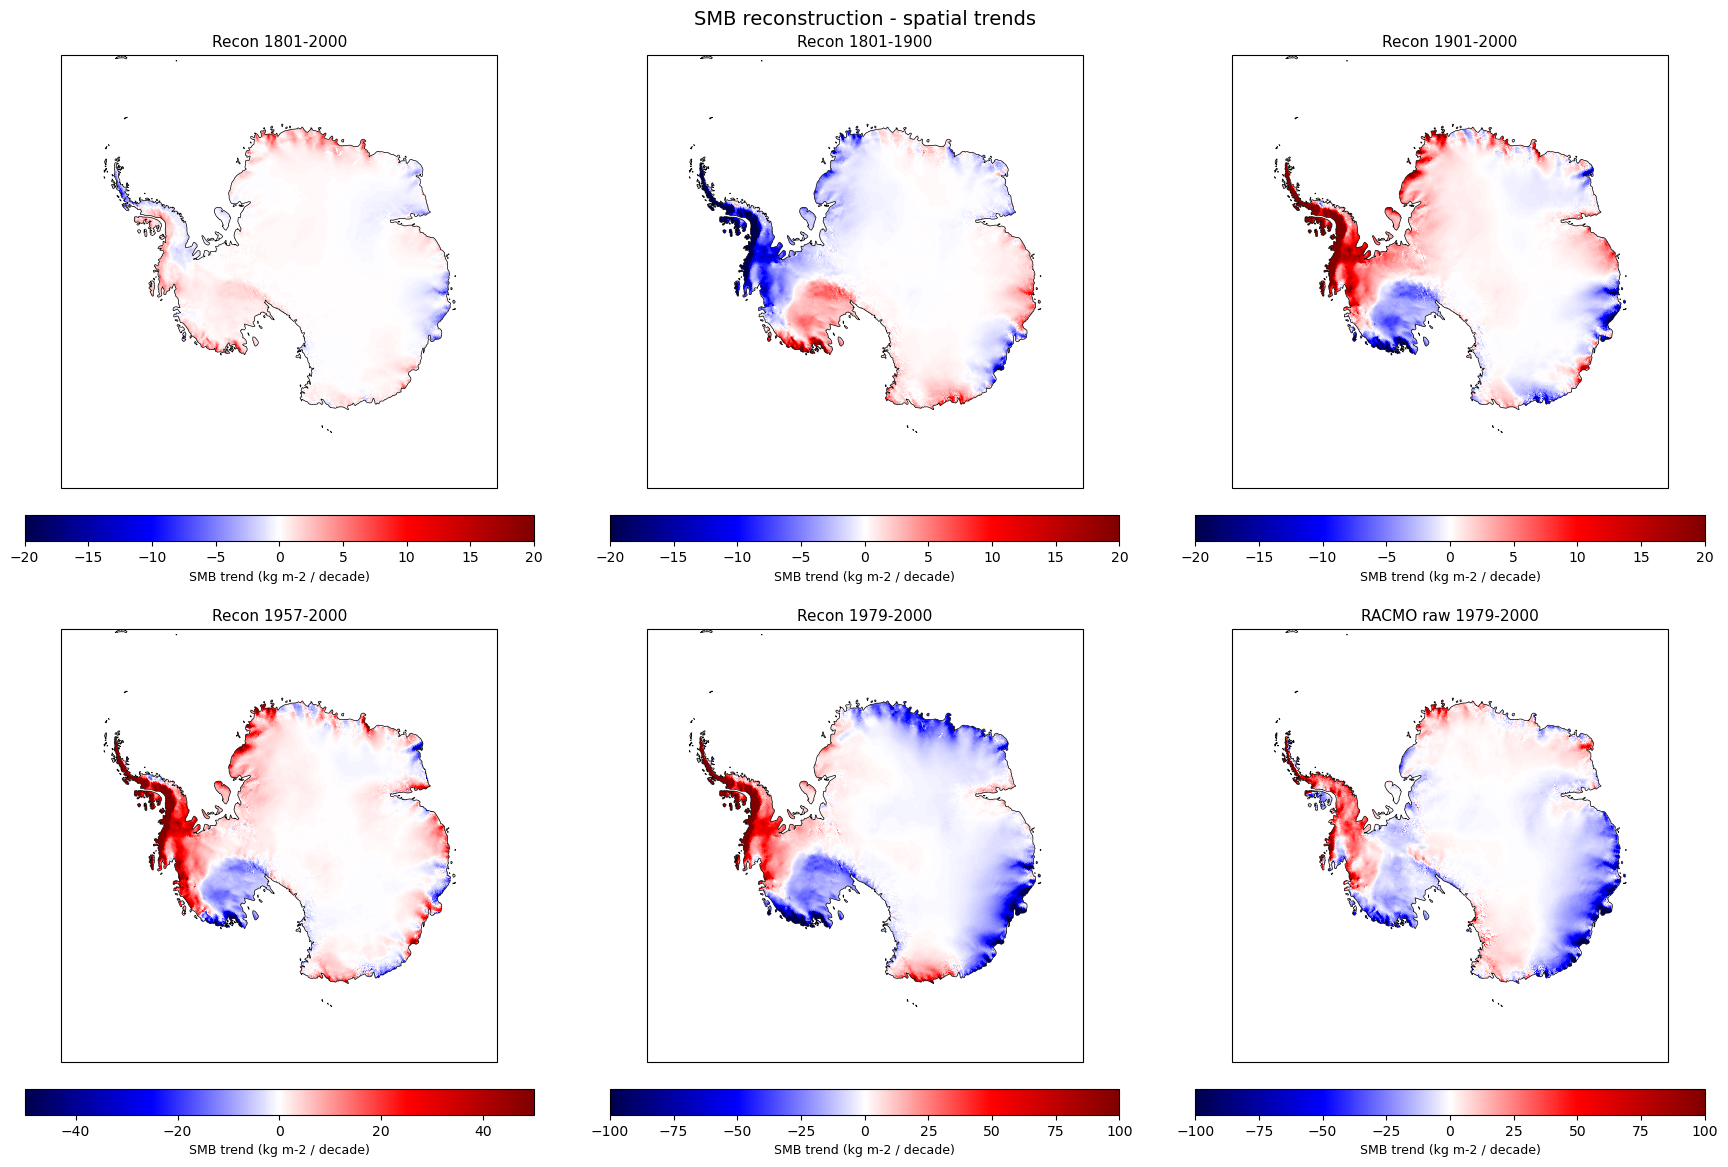

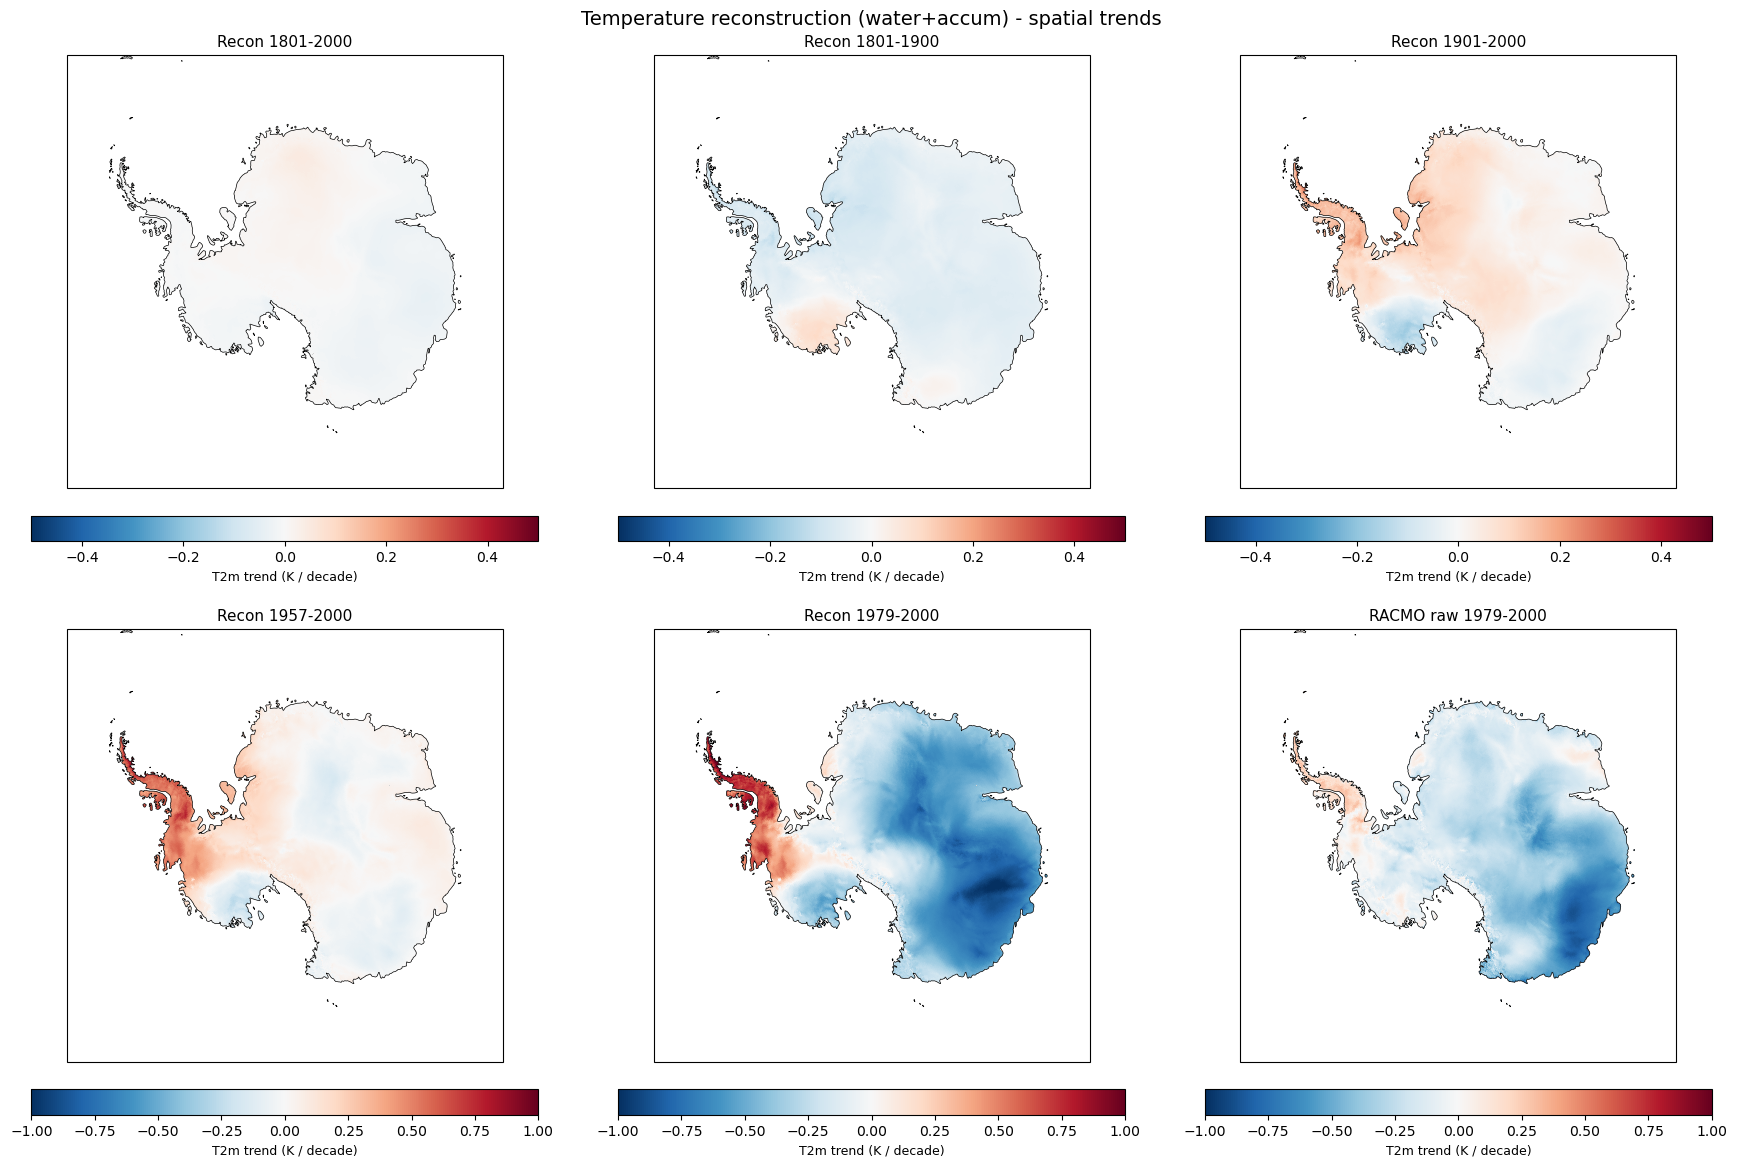

In [22]:
def spatial_trend(cube_3d, yr_start, yr_end, yr_offset=1801):
    i0, i1 = yr_start - yr_offset, yr_end - yr_offset
    sub = cube_3d[i0:i1 + 1]
    t = np.arange(sub.shape[0], dtype=float)
    X = np.vstack([t, np.ones_like(t)]).T
    beta, _, _, _ = np.linalg.lstsq(X, sub.reshape(sub.shape[0], -1), rcond=None)
    return (beta[0].reshape(sub.shape[1], sub.shape[2]) * 10)   # per decade

def polar_map(data_2d, title, cbar_label, vmin, vmax, cmap="RdBu_r"):
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": ccrs.SouthPolarStereo()})
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, data_2d, transform=ccrs.PlateCarree(),
                       vmin=vmin, vmax=vmax, cmap=cmap, zorder=1)
    plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8).set_label(cbar_label)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=12, pad=10); plt.tight_layout(); plt.show()

def six_panel(recon_cube, raw_da, cbar_label, cmap, vmaxes, suptitle):
    periods = [("Recon 1801-2000", recon_cube, 1801, 2000, vmaxes[0], 1801),
               ("Recon 1801-1900", recon_cube, 1801, 1900, vmaxes[1], 1801),
               ("Recon 1901-2000", recon_cube, 1901, 2000, vmaxes[2], 1801),
               ("Recon 1957-2000", recon_cube, 1957, 2000, vmaxes[3], 1801),
               ("Recon 1979-2000", recon_cube, 1979, 2000, vmaxes[4], 1801),
               ("RACMO raw 1979-2000", raw_da.sel(year=slice(1979, 2000)).values, 1979, 2000, vmaxes[5], 1979)]
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={"projection": ccrs.SouthPolarStereo()})
    for ax, (title, cube, y0, y1, vmax, off) in zip(axes.ravel(), periods):
        ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
        im = ax.pcolormesh(lon_racmo, lat_racmo, spatial_trend(cube, y0, y1, off),
                           transform=ccrs.PlateCarree(), vmin=-vmax, vmax=vmax, cmap=cmap, zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        ax.set_title(title, fontsize=11, pad=6)
        plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.85).set_label(cbar_label, fontsize=9)
    fig.suptitle(suptitle, fontsize=14); fig.tight_layout(); plt.show()

six_panel(racmo_smb_recon, smb_ann, "SMB trend (kg m-2 / decade)", "seismic",
          [20, 20, 20, 50, 100, 100], "SMB reconstruction - spatial trends")
six_panel(racmo_temp_recon, t2m_ann, "T2m trend (K / decade)", "RdBu_r",
          [0.5, 0.5, 0.5, 1.0, 1.0, 1.0], "Temperature reconstruction (water+accum) - spatial trends")

## 11. Reconstruction + observed extension to 2025

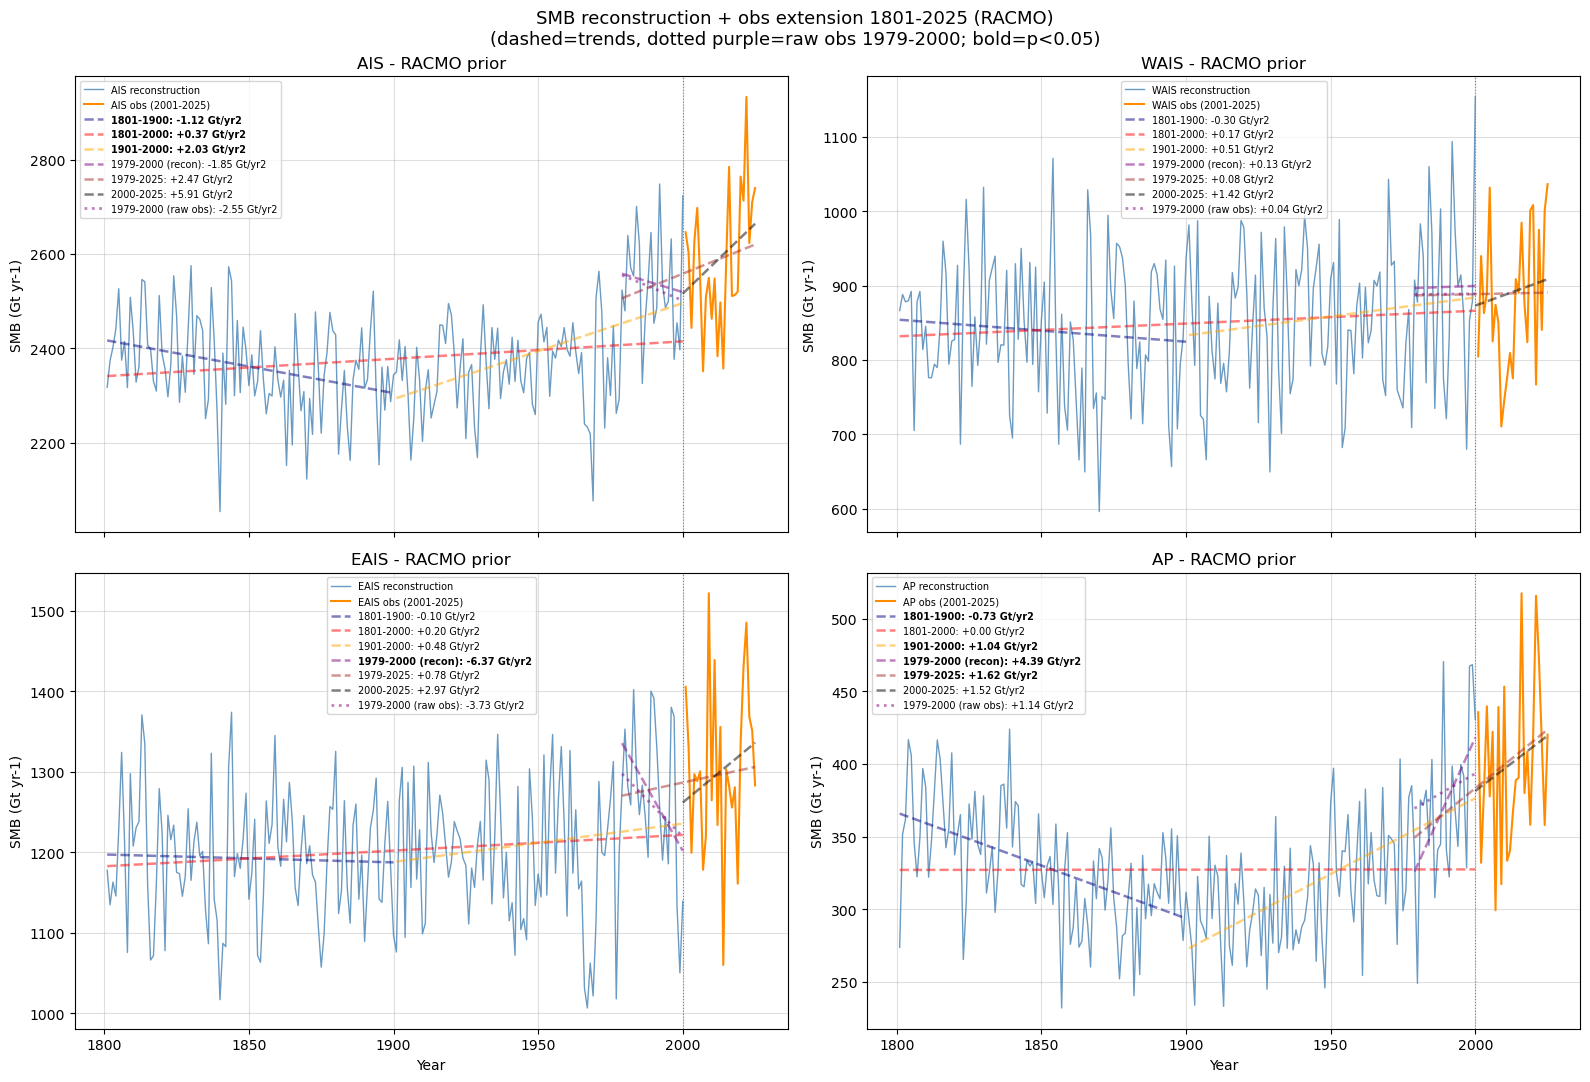

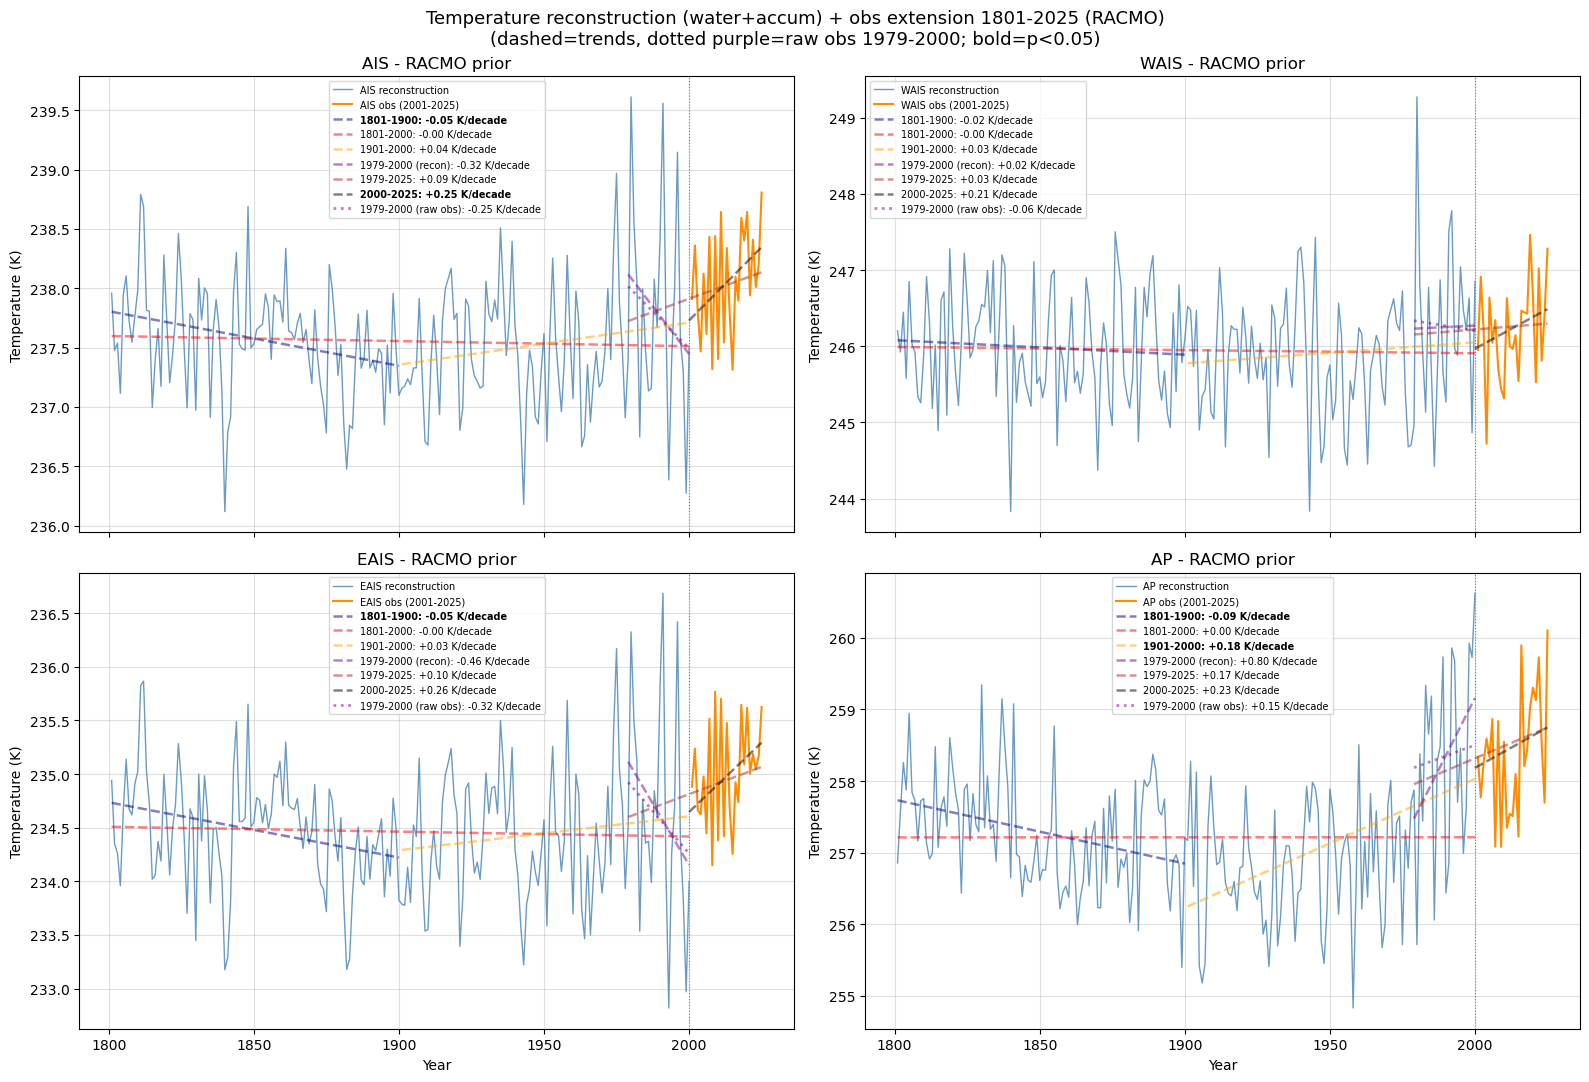

In [23]:
ext_years = np.concatenate([recon_years, np.arange(2001, 2026)])   # 1801-2025
trend_periods = [(1801, 1900, "navy", "1801-1900"), (1801, 2000, "red", "1801-2000"),
                 (1901, 2000, "orange", "1901-2000"), (1979, 2000, "purple", "1979-2000 (recon)"),
                 (1979, 2025, "brown", "1979-2025"), (2000, 2025, "black", "2000-2025")]
obs_years_1979_2000 = np.arange(1979, 2001)

def _extend(recon_ts, obs_full):
    return np.concatenate([recon_ts, np.asarray(obs_full)[22:]])   # append 2001-2025

def ext_grid(pairs, ylabel, unit, scale, sup):
    fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
    for ax, (region, recon_ts, obs_full) in zip(axes.ravel(), pairs):
        ts = _extend(recon_ts, obs_full); weights = []
        ax.plot(recon_years, ts[:200], color="steelblue", lw=1.0, alpha=0.8,
                label=f"{region} reconstruction"); weights.append("normal")
        ax.plot(np.arange(2001, 2026), ts[200:], color="darkorange", lw=1.5,
                label=f"{region} obs (2001-2025)"); weights.append("normal")
        ax.axvline(2000, color="gray", lw=0.8, ls=":")
        for (y1, y2, col, lbl) in trend_periods:
            idx = (ext_years >= y1) & (ext_years <= y2)
            if idx.sum() < 3: continue
            sl, ic, r, p, _ = stats.linregress(ext_years[idx].astype(float), ts[idx])
            ax.plot(ext_years[idx], sl*ext_years[idx]+ic, "--", color=col, lw=1.8, alpha=0.5,
                    label=f"{lbl}: {sl*scale:+.2f} {unit}")
            weights.append("bold" if p < 0.05 else "normal")
        obs_22 = np.asarray(obs_full)[:22]; v = np.isfinite(obs_22)
        if v.sum() > 2:
            sl, ic, r, p, _ = stats.linregress(obs_years_1979_2000[v].astype(float), obs_22[v])
            ax.plot(obs_years_1979_2000, sl*obs_years_1979_2000+ic, ":", color="purple", lw=2.0,
                    alpha=0.5, label=f"1979-2000 (raw obs): {sl*scale:+.2f} {unit}")
            weights.append("bold" if p < 0.05 else "normal")
        ax.set_title(f"{region} - RACMO prior"); ax.set_ylabel(ylabel); ax.grid(alpha=0.4)
        leg = ax.legend(fontsize=7)
        for txt, wt in zip(leg.get_texts(), weights): txt.set_fontweight(wt)
    for ax in axes[-1, :]: ax.set_xlabel("Year")
    fig.suptitle(sup, fontsize=13); fig.tight_layout(); plt.show()

smb_pairs = [("AIS", ais_rac_recon, ais_rac), ("WAIS", wais_rac_recon, wais_rac),
             ("EAIS", eais_rac_recon, eais_rac), ("AP", ap_rac_recon, ap_rac)]
temp_pairs = [("AIS", ais_temp_recon, rac_t2m_full["AIS"]), ("WAIS", wais_temp_recon, rac_t2m_full["WAIS"]),
              ("EAIS", eais_temp_recon, rac_t2m_full["EAIS"]), ("AP", ap_temp_recon, rac_t2m_full["AP"])]
ext_grid(smb_pairs, "SMB (Gt yr-1)", "Gt/yr2", 1,
         "SMB reconstruction + obs extension 1801-2025 (RACMO)\n(dashed=trends, dotted purple=raw obs 1979-2000; bold=p<0.05)")
ext_grid(temp_pairs, "Temperature (K)", "K/decade", 10,
         "Temperature reconstruction (water+accum) + obs extension 1801-2025 (RACMO)\n(dashed=trends, dotted purple=raw obs 1979-2000; bold=p<0.05)")

### 10-year rolling means (1801–2025)

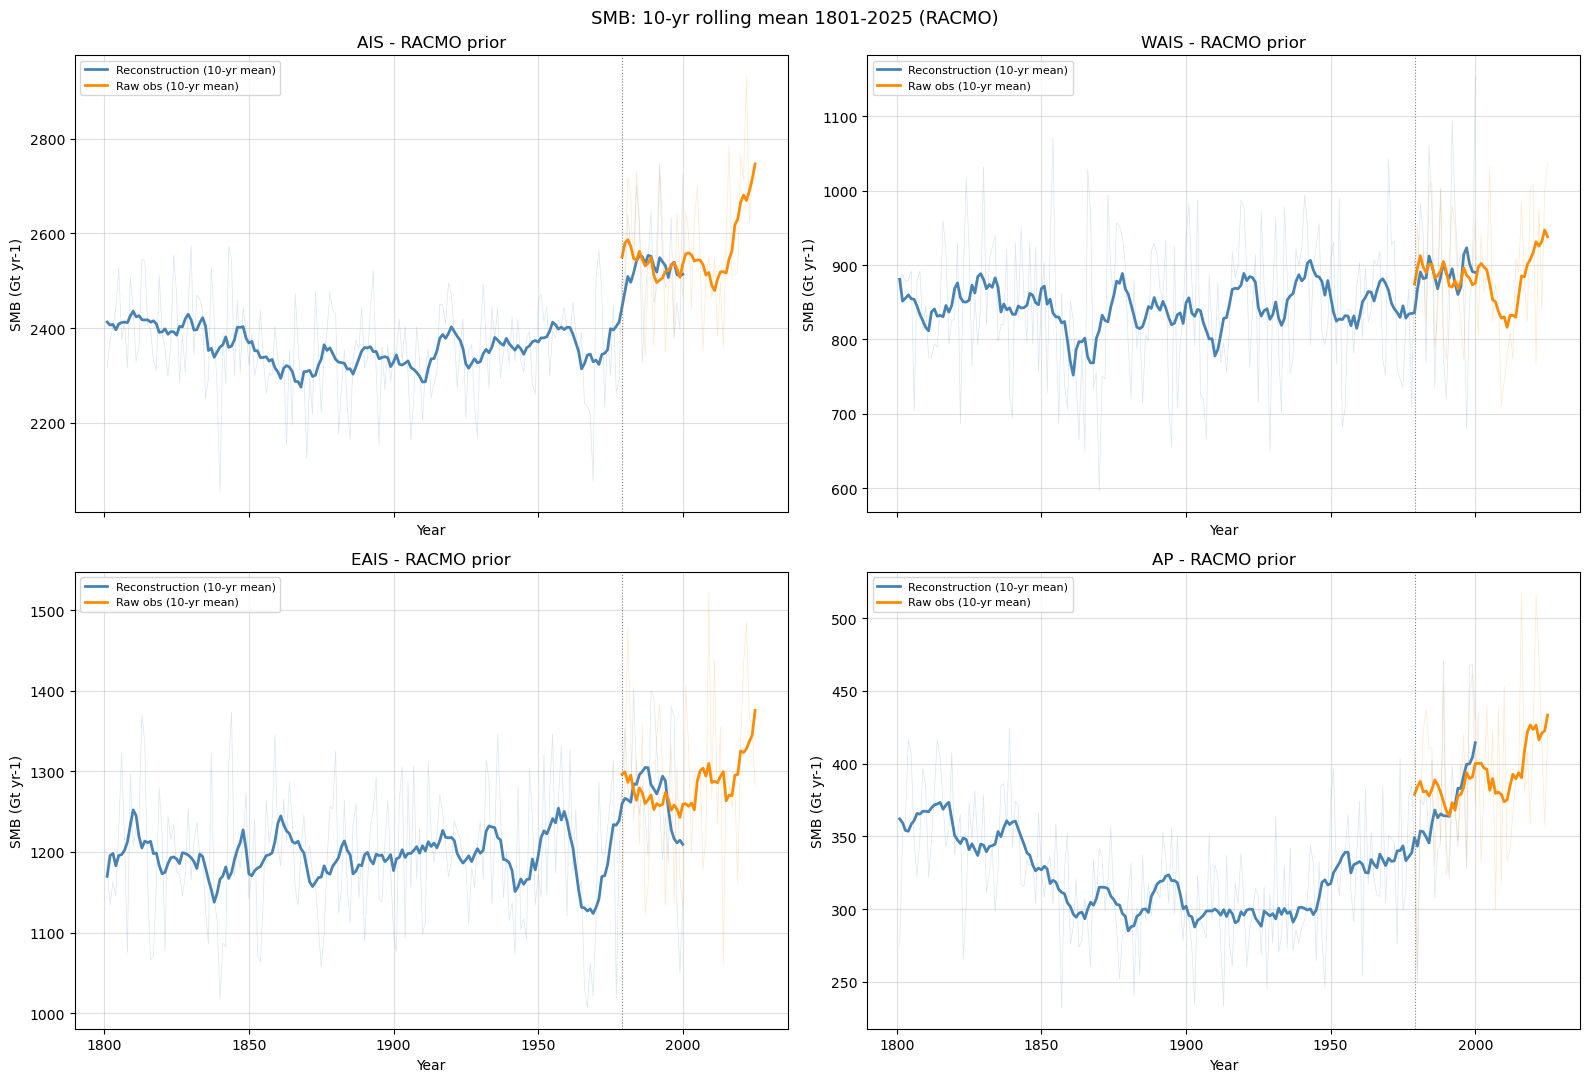

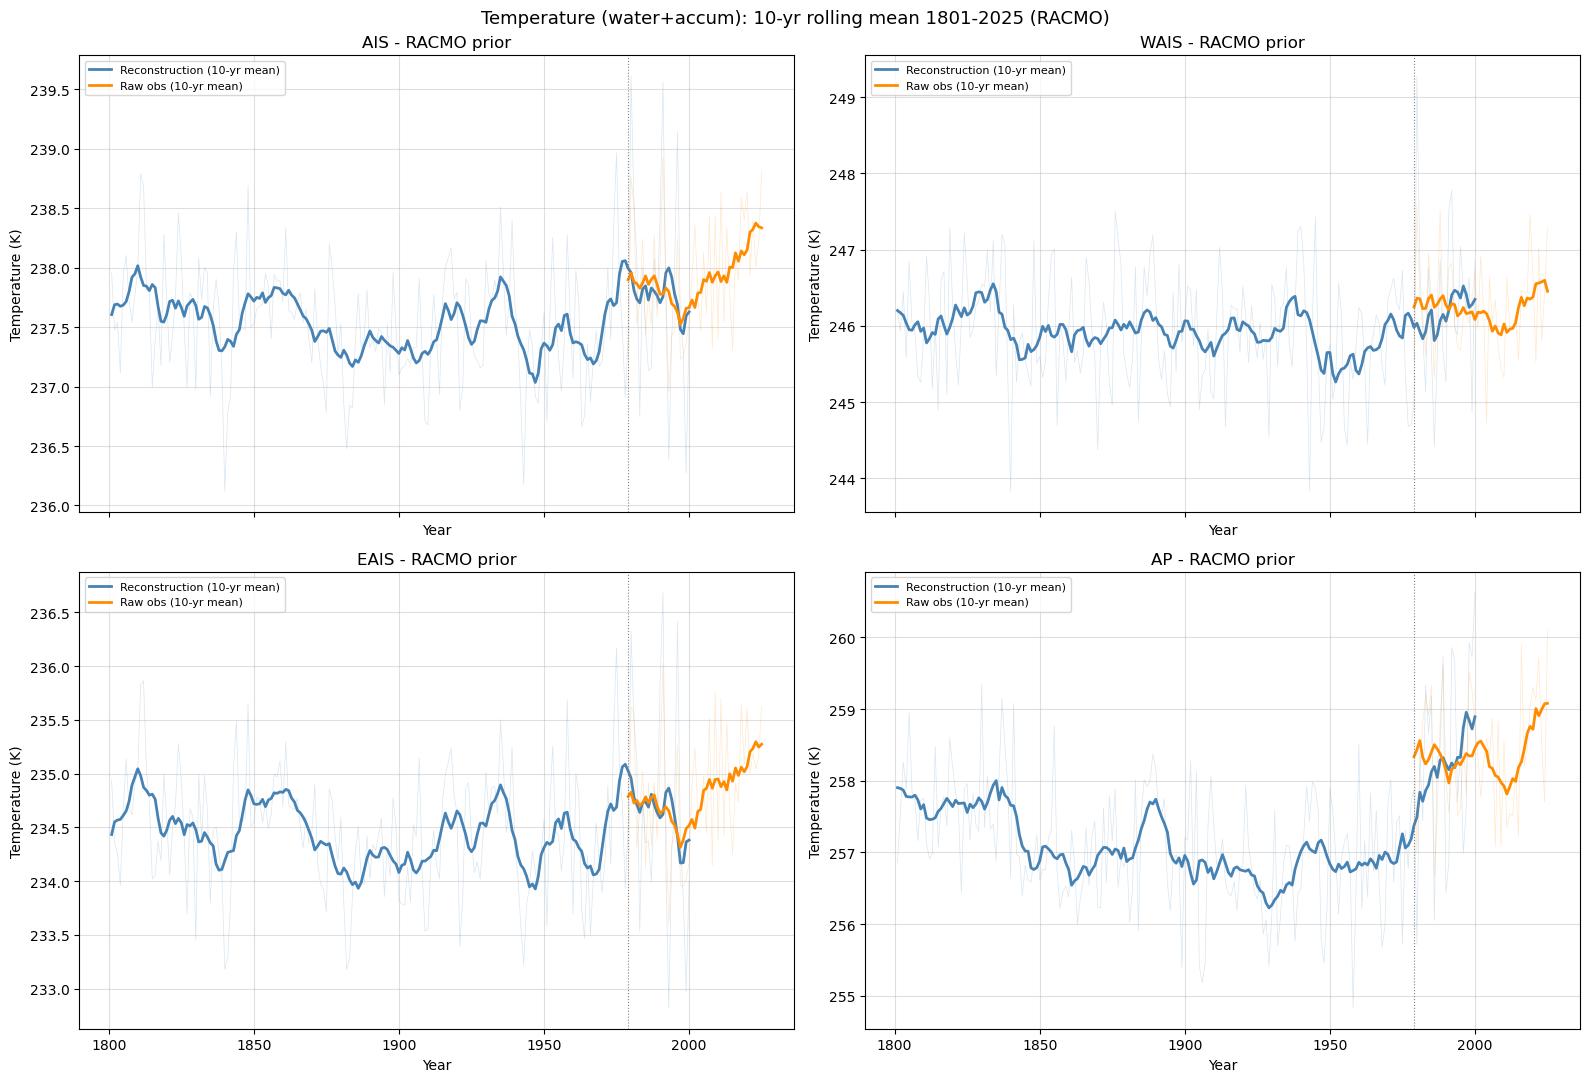

In [24]:
def rolling_mean(ts, window=10):
    return pd.Series(ts).rolling(window, center=True, min_periods=1).mean().values

obs_years_plot = np.arange(1979, 2026)
def rolling_grid(pairs, ylabel, sup):
    fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
    for ax, (region, recon_ts, obs_full) in zip(axes.ravel(), pairs):
        obs_ts = np.asarray(obs_full)
        ax.plot(recon_years, recon_ts, color="steelblue", lw=0.5, alpha=0.2)
        ax.plot(recon_years, rolling_mean(recon_ts), color="steelblue", lw=2.0, label="Reconstruction (10-yr mean)")
        ax.plot(obs_years_plot, obs_ts, color="darkorange", lw=0.5, alpha=0.2)
        ax.plot(obs_years_plot, rolling_mean(obs_ts), color="darkorange", lw=2.0, label="Raw obs (10-yr mean)")
        ax.axvline(1979, color="gray", lw=0.8, ls=":")
        ax.set_title(f"{region} - RACMO prior"); ax.set_ylabel(ylabel); ax.set_xlabel("Year")
        ax.legend(fontsize=8); ax.grid(alpha=0.4)
    fig.suptitle(sup, fontsize=13); fig.tight_layout(); plt.show()

rolling_grid(smb_pairs, "SMB (Gt yr-1)", "SMB: 10-yr rolling mean 1801-2025 (RACMO)")
rolling_grid(temp_pairs, "Temperature (K)", "Temperature (water+accum): 10-yr rolling mean 1801-2025 (RACMO)")

## 12. Sea-level mitigation (to 2025)

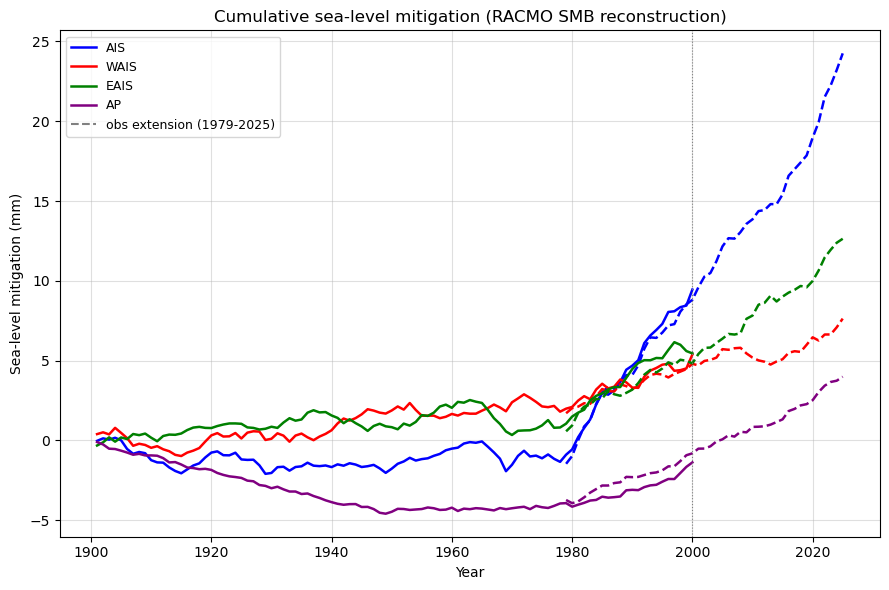

In [25]:
def sea_level_mitigation(ts, baseline=slice(0, 100)):
    return np.cumsum(ts - np.mean(ts[baseline])) / 361.8    # Gt -> mm SLE

def extend_slm(recon_ts, obs_ts, baseline=slice(0, 100)):
    base = np.mean(recon_ts[baseline])
    cum_to_1978 = np.sum(recon_ts[:178] - base) / 361.8
    return cum_to_1978 + np.cumsum((np.asarray(obs_ts) - base) / 361.8)

cent_years = np.arange(1901, 2001)
fig, ax = plt.subplots(figsize=(9, 6))
for recon_ts, obs_ts, name, col in [
        (ais_rac_recon, ais_rac, "AIS", "blue"), (wais_rac_recon, wais_rac, "WAIS", "red"),
        (eais_rac_recon, eais_rac, "EAIS", "green"), (ap_rac_recon, ap_rac, "AP", "purple")]:
    slm = sea_level_mitigation(recon_ts)
    ax.plot(cent_years, slm[100:], color=col, lw=1.8, label=name)
    ax.plot(years_obs, extend_slm(recon_ts, obs_ts), color=col, lw=1.8, ls="--")
ax.plot([], [], color="gray", lw=1.5, ls="--", label="obs extension (1979-2025)")
ax.axvline(2000, color="gray", lw=0.8, ls=":")
ax.set_title("Cumulative sea-level mitigation (RACMO SMB reconstruction)")
ax.set_xlabel("Year"); ax.set_ylabel("Sea-level mitigation (mm)")
ax.legend(fontsize=9); ax.grid(alpha=0.4); plt.tight_layout(); plt.show()

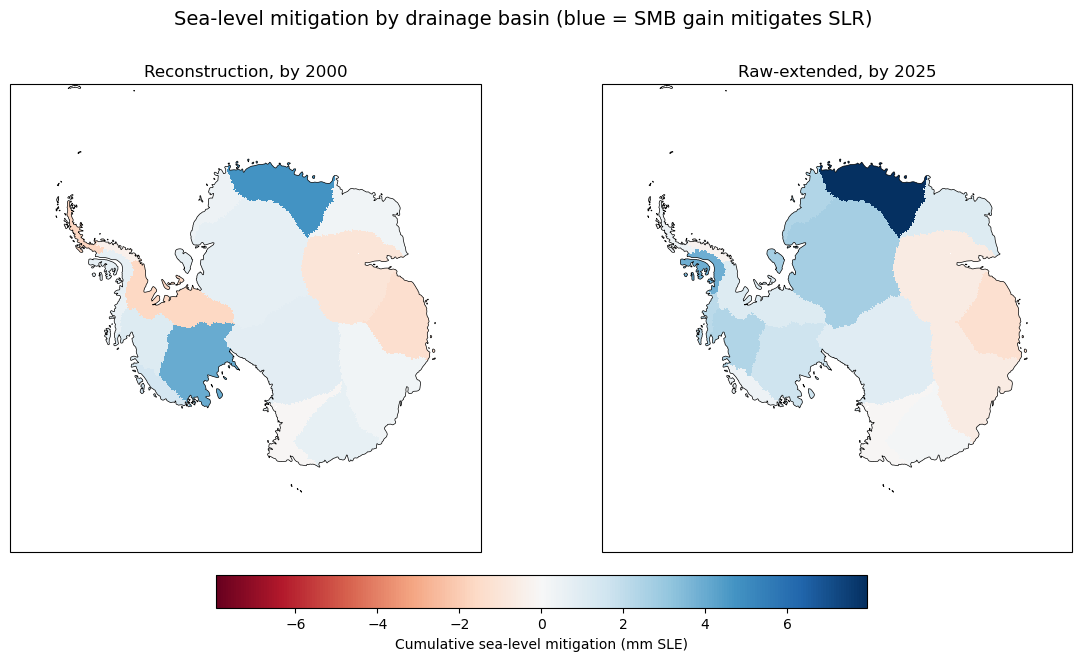

In [47]:
# --- Sea-level mitigation by drainage basin: recon->2000 and raw-extended->2025 ---
def basin_total(field3d, years, bid):
    mk = basin_mask == bid
    return np.array([np.nansum(np.where(mk, field3d[t] * cell_area_m2, 0)) / 1e12
                     for t in range(field3d.shape[0])])

def sea_level_mitigation(ts, baseline=slice(0, 100)):
    return np.cumsum(ts - np.mean(ts[baseline])) / 361.8          # Gt anomaly -> mm SLE

def extend_slm(recon_ts, obs_ts, baseline=slice(0, 100)):
    base = np.mean(recon_ts[baseline])
    cum_to_1978 = np.sum(recon_ts[:178] - base) / 361.8           # running total to end of 1978
    return cum_to_1978 + np.cumsum((np.asarray(obs_ts) - base) / 361.8)

slm2000, slm2025 = {}, {}
for bid in basin_ids_unique:
    rc = basin_total(racmo_smb_recon, recon_years, bid)           # 1801-2000
    ob = basin_total(smb_ann.values,  years_obs,   bid)           # 1979-2025 (raw RACMO)
    slm2000[bid] = sea_level_mitigation(rc)[-1]                   # cumulative to 2000
    slm2025[bid] = extend_slm(rc, ob)[-1]                         # cumulative to 2025

def paint(d):
    f = np.full(basin_mask.shape, np.nan)
    for bid, v in d.items():
        f[basin_mask == bid] = v
    return f

vmax = np.nanmax(np.abs(list(slm2000.values()) + list(slm2025.values())))
fig, axes = plt.subplots(1, 2, figsize=(14, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
im = None
for ax, (d, title) in zip(axes, [(slm2000, "Reconstruction, by 2000"),
                                  (slm2025, "Raw-extended, by 2025")]):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint(d), transform=ccrs.PlateCarree(),
                       vmin=-vmax, vmax=vmax, cmap="RdBu", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=12, pad=6)
cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.04, shrink=0.6)
cb.set_label("Cumulative sea-level mitigation (mm SLE)")
fig.suptitle("Sea-level mitigation by drainage basin (blue = SMB gain mitigates SLR)", fontsize=14)
plt.show()


## 13. Temperature–SMB sensitivity

In [46]:
def log_sensitivity(T_cube, P_cube):
    logP = np.where(P_cube > 0, np.log(P_cube), np.nan)
    Ta = T_cube - np.nanmean(T_cube, axis=0)
    Pa = logP - np.nanmean(logP, axis=0)
    den = np.nansum(Ta**2, axis=0)
    return 100.0 * np.nansum(Ta * Pa, axis=0) / np.where(den > 0, den, np.nan)

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/1746123269.py:3: RuntimeWarning: invalid value encountered in log
  logP = np.where(P_cube > 0, np.log(P_cube), np.nan)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/1746123269.py:4: RuntimeWarning: Mean of empty slice
  Ta   = T_cube - np.nanmean(T_cube, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/1746123269.py:5: RuntimeWarning: Mean of empty slice
  Pa   = logP  - np.nanmean(logP,  axis=0)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/1746123269.py:3: RuntimeWarning: invalid value encountered in log
  logP = np.where(P_cube > 0, np.log(P_cube), np.nan)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/17461

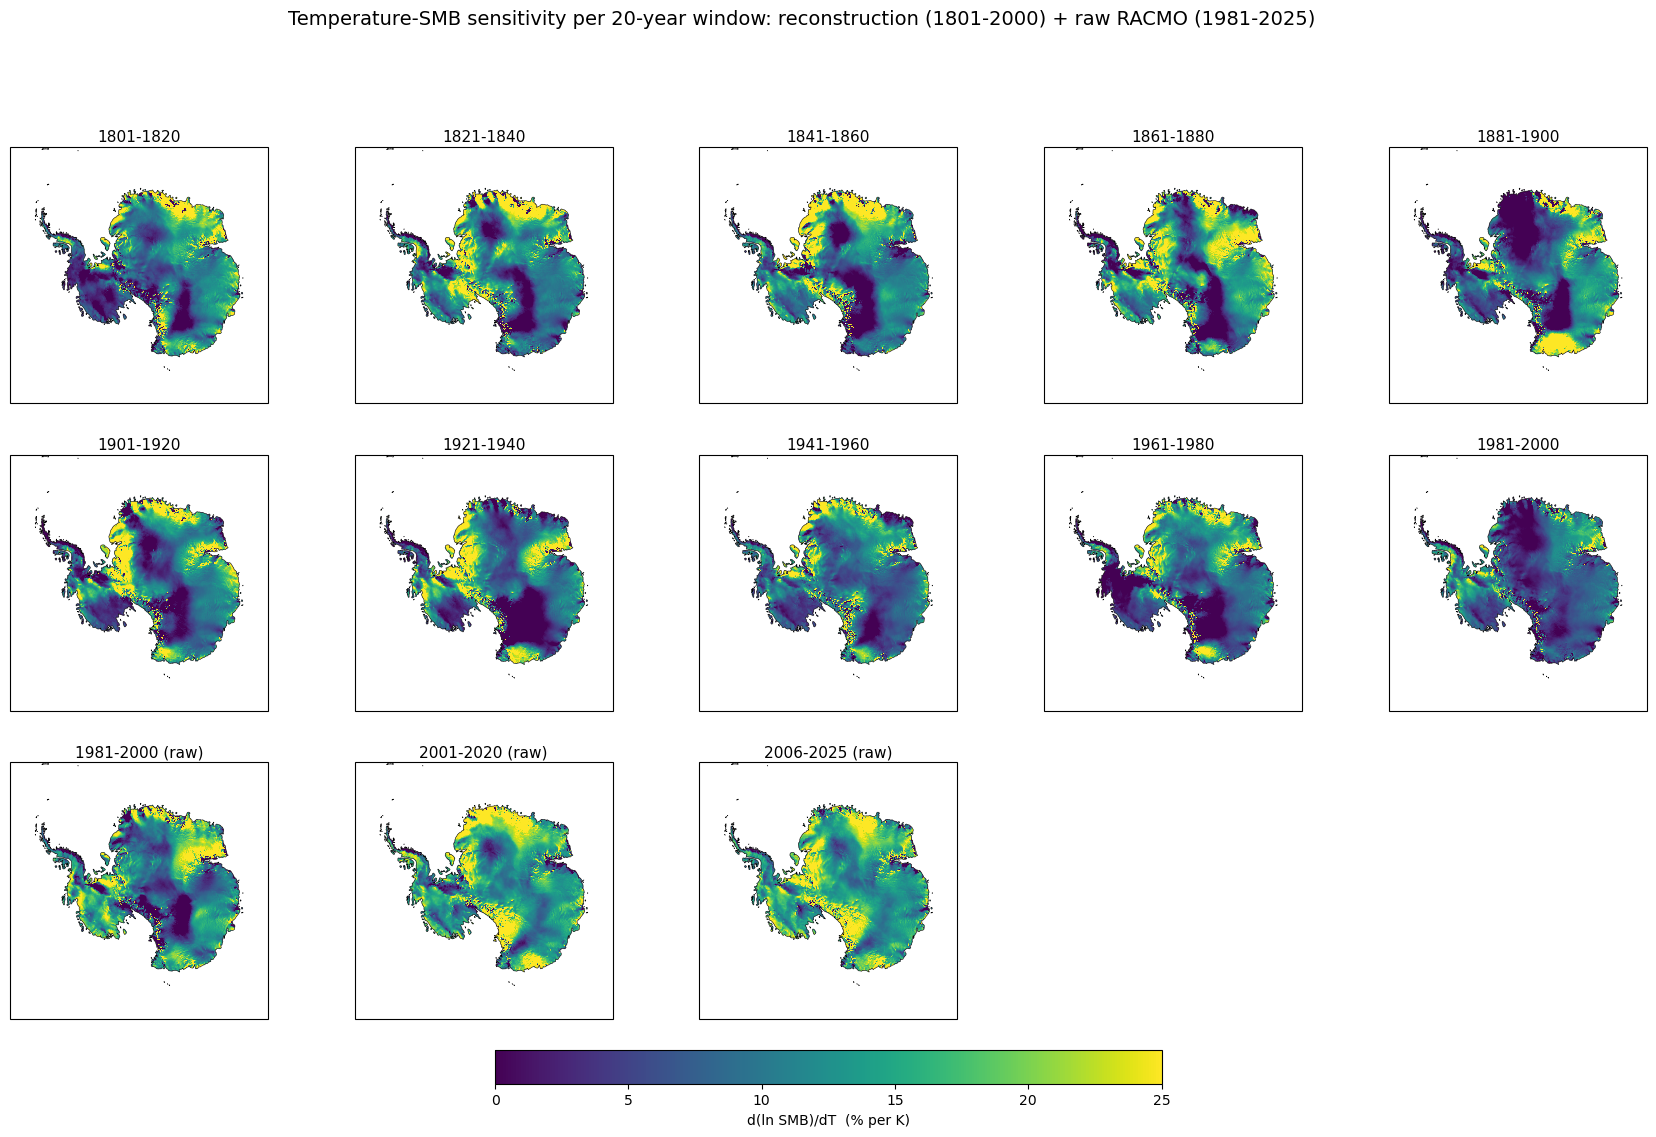

In [45]:
# --- T-SMB sensitivity per 20-yr window: reconstruction (1801-2000) + raw RACMO windows ---
def log_sensitivity(T_cube, P_cube):
    logP = np.where(P_cube > 0, np.log(P_cube), np.nan)
    Ta   = T_cube - np.nanmean(T_cube, axis=0)
    Pa   = logP  - np.nanmean(logP,  axis=0)
    den  = np.nansum(Ta ** 2, axis=0)
    return 100.0 * np.nansum(Ta * Pa, axis=0) / np.where(den > 0, den, np.nan)

def sens_masked(T, P):                       # keep to grounded ice for consistent panels
    return np.where(ice_sheet, log_sensitivity(T, P), np.nan)

panels = []
for y in range(1801, 2000, 20):              # ten 20-yr reconstruction windows
    i0, i1 = y - 1801, y + 19 - 1801 + 1
    panels.append((f"{y}-{y+19}", racmo_temp_recon[i0:i1], racmo_smb_recon[i0:i1]))
for y1, y2 in [(1981, 2000), (2001, 2020), (2006, 2025)]:     # raw RACMO2.4p1 windows
    panels.append((f"{y1}-{y2} (raw)",
                   t2m_ann.sel(year=slice(y1, y2)).values,
                   smb_ann.sel(year=slice(y1, y2)).values))

n = len(panels); ncols = 5; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.3, nrows * 4.6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})
axf = axes.ravel(); im = None
for ax, (label, T, P) in zip(axf, panels):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, sens_masked(T, P), transform=ccrs.PlateCarree(),
                       vmin=0, vmax=25, cmap="viridis", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color="black", zorder=3)
    ax.set_title(label, fontsize=11, pad=4)
for ax in axf[n:]:
    ax.axis("off")
cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.03, shrink=0.4)
cb.set_label("d(ln SMB)/dT  (% per K)")
fig.suptitle("Temperature-SMB sensitivity per 20-year window: reconstruction (1801-2000) + raw RACMO (1981-2025)",
             fontsize=14)
plt.show()


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packag

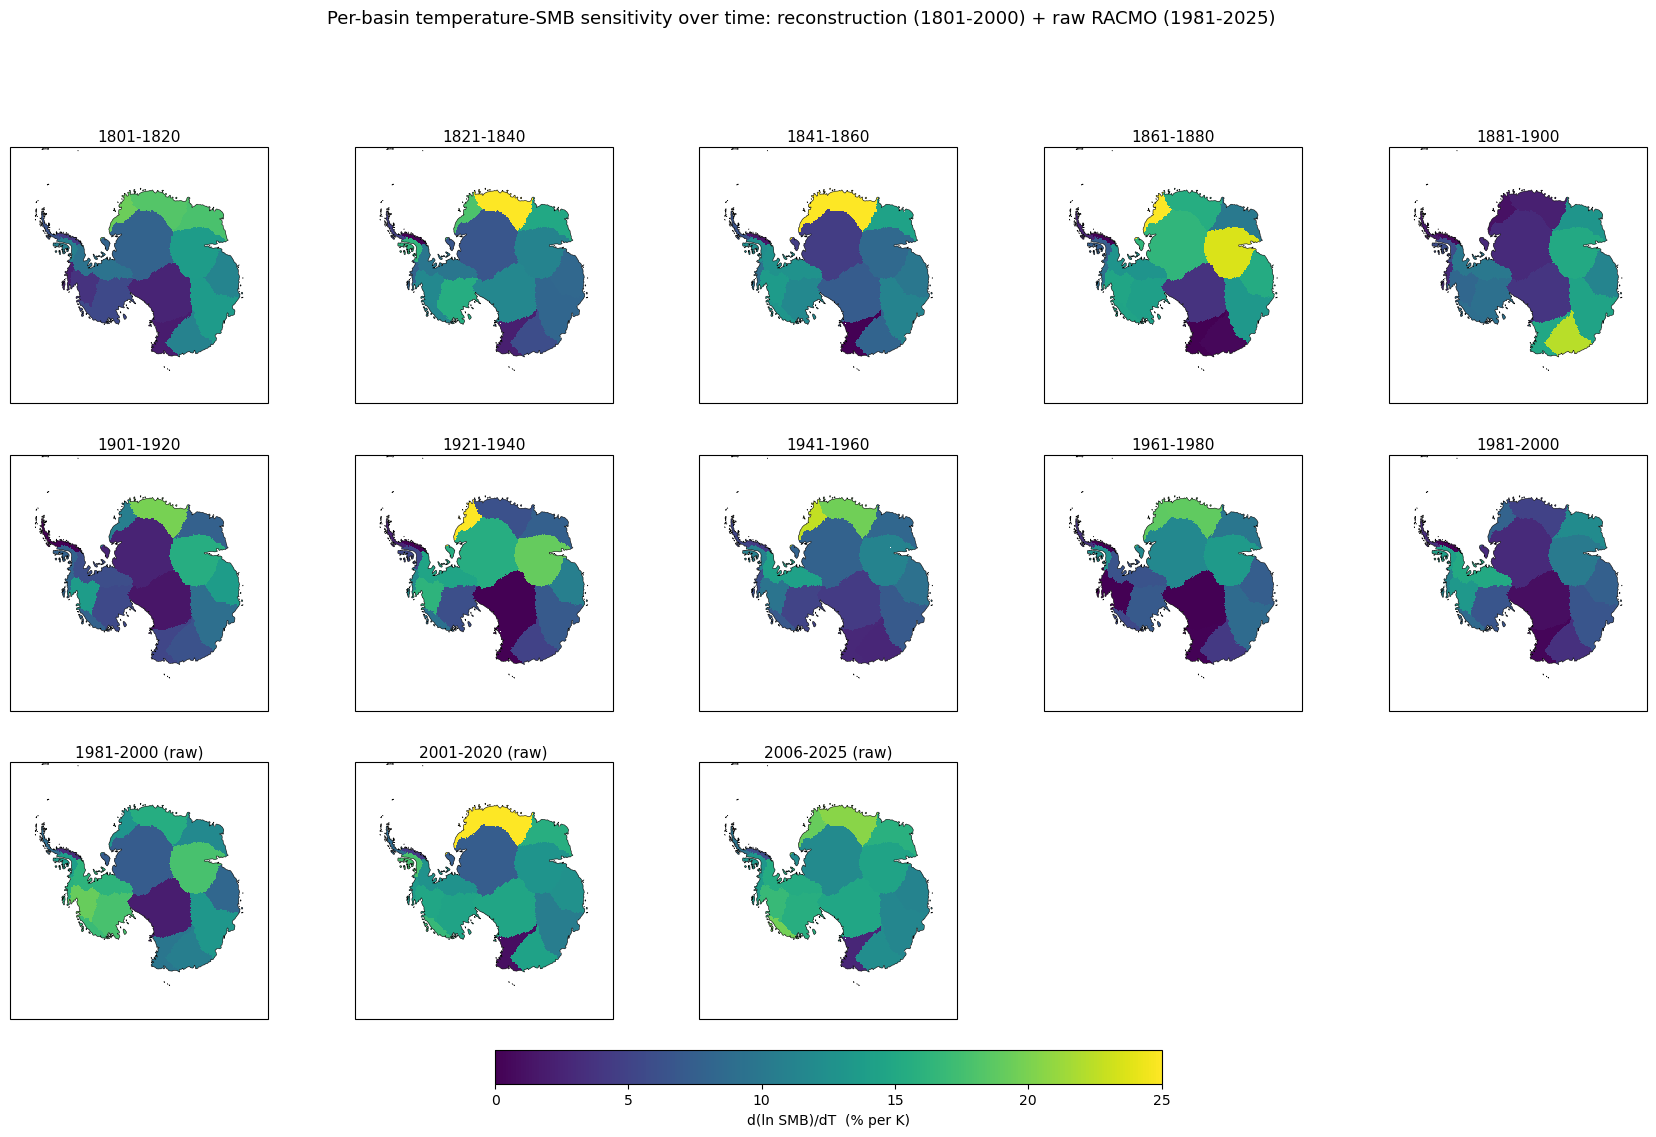

In [87]:
# --- Per-basin T-SMB sensitivity maps: reconstruction (20-yr, 1801-2000) + raw RACMO windows ---
recon_wins = [(y, y + 19, "recon") for y in range(1801, 2000, 20)]           # ten reconstruction windows
raw_wins   = [(1981, 2000, "raw"), (2001, 2020, "raw"), (2006, 2025, "raw")] # raw RACMO2.4p1 windows
all_wins   = recon_wins + raw_wins

# basin-mean T2m and ln(SMB) series: reconstruction (1801-2000) and raw RACMO (1979-2025)
basin_T     = {b: weighted_avg_series(racmo_temp_recon, basin_mask == b) for b in basin_ids_unique}
basin_lnP   = {b: np.log(np.where((p := weighted_avg_series(racmo_smb_recon, basin_mask == b)) > 0, p, np.nan))
               for b in basin_ids_unique}
basin_T_raw   = {b: weighted_avg_series(t2m_ann.values, basin_mask == b) for b in basin_ids_unique}
basin_lnP_raw = {b: np.log(np.where((p := weighted_avg_series(smb_ann.values, basin_mask == b)) > 0, p, np.nan))
                 for b in basin_ids_unique}

def sens_window(y1, y2, src):
    (T, lnP, off) = (basin_T, basin_lnP, 1801) if src == "recon" else (basin_T_raw, basin_lnP_raw, 1979)
    i0, i1 = y1 - off, y2 - off + 1
    out = {}
    for b in basin_ids_unique:
        t, lp = T[b][i0:i1], lnP[b][i0:i1]
        ta, la = t - np.nanmean(t), lp - np.nanmean(lp)
        den = np.nansum(ta ** 2)
        out[b] = 100 * np.nansum(ta * la) / den if den > 0 else np.nan
    return out

def paint(dct):
    f = np.full(basin_mask.shape, np.nan)
    for b, v in dct.items():
        f[basin_mask == b] = v
    return f

nwin = len(all_wins); ncols = 5; nrows = int(np.ceil(nwin / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.3, nrows * 4.6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})
axf = axes.ravel(); im = None
for ax, (y1, y2, src) in zip(axf, all_wins):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint(sens_window(y1, y2, src)), transform=ccrs.PlateCarree(),
                       vmin=0, vmax=25, cmap="viridis", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color="black", zorder=3)
    ax.set_title(f"{y1}-{y2}" + (" (raw)" if src == "raw" else ""), fontsize=11, pad=4)
for ax in axf[nwin:]:
    ax.axis("off")
cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.03, shrink=0.4)
cb.set_label("d(ln SMB)/dT  (% per K)")
fig.suptitle("Per-basin temperature-SMB sensitivity over time: reconstruction (1801-2000) + raw RACMO (1981-2025)",
             fontsize=13)
plt.show()


## 15. Independent validation vs MERRA-2

MERRA-2 (`M2TMNXFLX`: `PRECTOT`, `TLML`) as an independent reference. Regridded onto the
ANT11 grid with scipy `RegularGridInterpolator` (bilinear; no xesmf). MERRA-2 begins 1980,
so the 1979–2000 skill window uses 1980–2000; comparisons are year-aligned.

In [28]:
import glob
from scipy.interpolate import RegularGridInterpolator

merra_dir = os.path.expanduser("~/DataFiles/M2TMNXFLX")
mfiles = sorted(f for f in glob.glob(f"{merra_dir}/*") if f.endswith((".nc4", ".dap.nc4")))
print(f"{len(mfiles)} MERRA-2 files")
merra_ds = xr.concat([xr.open_dataset(f) for f in mfiles], dim="time")

secs = merra_ds["time"].dt.days_in_month * 86400.0
merra_acc = ((merra_ds["PRECTOT"] * secs).groupby("time.year").sum("time")
             .sel(year=slice(1979, 2025)))          # kg m-2 yr-1
merra_t2m = (merra_ds["TLML"].groupby("time.year").mean("time")
             .sel(year=slice(1979, 2025)))          # K
merra_years = merra_acc["year"].values

def regrid_to_ant11(da):
    """Bilinear regrid a (year, lat, lon) regular-grid DataArray onto the ANT11 grid."""
    mlat = da["lat"].values; mlon = da["lon"].values
    vals = da.values
    if mlat[0] > mlat[-1]:
        mlat = mlat[::-1]; vals = vals[:, ::-1, :]
    if mlon[0] > mlon[-1]:
        mlon = mlon[::-1]; vals = vals[:, :, ::-1]
    pts = np.stack([lat_racmo.ravel(),
                    np.clip(lon_racmo.ravel(), mlon.min(), mlon.max())], -1)
    out = np.empty((vals.shape[0], NY, NX), dtype=float)
    for t in range(vals.shape[0]):
        rgi = RegularGridInterpolator((mlat, mlon), vals[t],
                                      bounds_error=False, fill_value=np.nan)
        out[t] = rgi(pts).reshape(NY, NX)
    return xr.DataArray(out, dims=("year", "rlat", "rlon"),
                        coords={"year": da["year"].values})

merra_ann     = regrid_to_ant11(merra_acc)          # SMB/precip on ANT11
merra_t2m_ann = regrid_to_ant11(merra_t2m)          # T2m on ANT11
print("MERRA-2 on ANT11:", merra_ann.shape, "years", int(merra_years.min()), "-", int(merra_years.max()))

# Basin series
merra_basin = basin_sums_Gt(merra_ann.values, merra_years)
smb_merra = {"AIS":  merra_basin.sum(axis=1).astype(float),
             "WAIS": merra_basin[[3,7,8,9,10]].sum(axis=1).astype(float),
             "EAIS": merra_basin[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float),
             "AP":   merra_basin[[4,5,6]].sum(axis=1).astype(float)}
t2m_merra = {r: basin_mean_series(merra_t2m_ann.values, merra_years, masks[r]) for r in masks}

516 MERRA-2 files
MERRA-2 on ANT11: (43, 591, 726) years 1980 - 2022


### Basin skill tables — correlation & anomaly-based CE (RACMO / MERRA-2)

In [29]:
ov_years = np.arange(1979, 2001)
recon_smb = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}
recon_t2m = {"AIS": ais_temp_recon, "WAIS": wais_temp_recon, "EAIS": eais_temp_recon, "AP": ap_temp_recon}

smb_obs = {"RACMO":  {r: pd.Series(np.array(v), index=years_obs) for r, v in
                      zip(["AIS","WAIS","EAIS","AP"], [ais_rac, wais_rac, eais_rac, ap_rac])},
           "MERRA2": smb_merra}
t2m_obs = {"RACMO":  {r: rac_t2m_full[r] for r in masks}, "MERRA2": t2m_merra}

def _yrs(recon_full, obs):
    rs = pd.Series(recon_full, index=recon_years)
    ys = [y for y in ov_years if y in obs.index and np.isfinite(obs.loc[y]) and np.isfinite(rs.loc[y])]
    return rs, ys
def yr_corr(recon_full, obs):
    rs, ys = _yrs(recon_full, obs)
    return np.corrcoef(rs.loc[ys], obs.loc[ys])[0, 1] if len(ys) >= 3 else np.nan
def yr_ce_anom(recon_full, obs):
    rs, ys = _yrs(recon_full, obs)
    if len(ys) < 3: return np.nan
    o = obs.loc[ys].values; p = rs.loc[ys].values
    oa = o - o.mean(); pa = p - p.mean(); den = np.sum(oa**2)
    return 1.0 - np.sum((oa - pa)**2) / den if den > 0 else np.nan

for metric_name, fn in [("Correlation (Pearson r)", yr_corr),
                        ("Coefficient of efficiency (anomaly-based)", yr_ce_anom)]:
    for var, recon, obs in [("SMB", recon_smb, smb_obs), ("Temperature", recon_t2m, t2m_obs)]:
        print("=" * 56)
        print(f"{var} - {metric_name} (1979-2000)".center(56))
        print("=" * 56)
        print(f"{'Region':<8}{'vs RACMO':>20}{'vs MERRA-2':>20}")
        print("-" * 56)
        for r in ["AIS", "WAIS", "EAIS", "AP"]:
            vals = [fn(recon[r], obs[src][r]) for src in ["RACMO", "MERRA2"]]
            print(f"{r:<8}" + "".join(f"{v:>20.3f}" for v in vals))
        print()

       SMB - Correlation (Pearson r) (1979-2000)        
Region              vs RACMO          vs MERRA-2
--------------------------------------------------------
AIS                    0.519               0.505
WAIS                   0.654               0.575
EAIS                   0.231               0.226
AP                     0.810               0.839

   Temperature - Correlation (Pearson r) (1979-2000)    
Region              vs RACMO          vs MERRA-2
--------------------------------------------------------
AIS                    0.828               0.727
WAIS                   0.751               0.791
EAIS                   0.822               0.718
AP                     0.701               0.633

SMB - Coefficient of efficiency (anomaly-based) (1979-2000)
Region              vs RACMO          vs MERRA-2
--------------------------------------------------------
AIS                    0.141               0.206
WAIS                  -0.369              -0.427
EAIS            

### Spatial correlation & CE maps (RACMO / MERRA-2)

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/2040293288.py:2: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/2040293288.py:2: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/2040293288.py:2: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/2040293288.py:2: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)


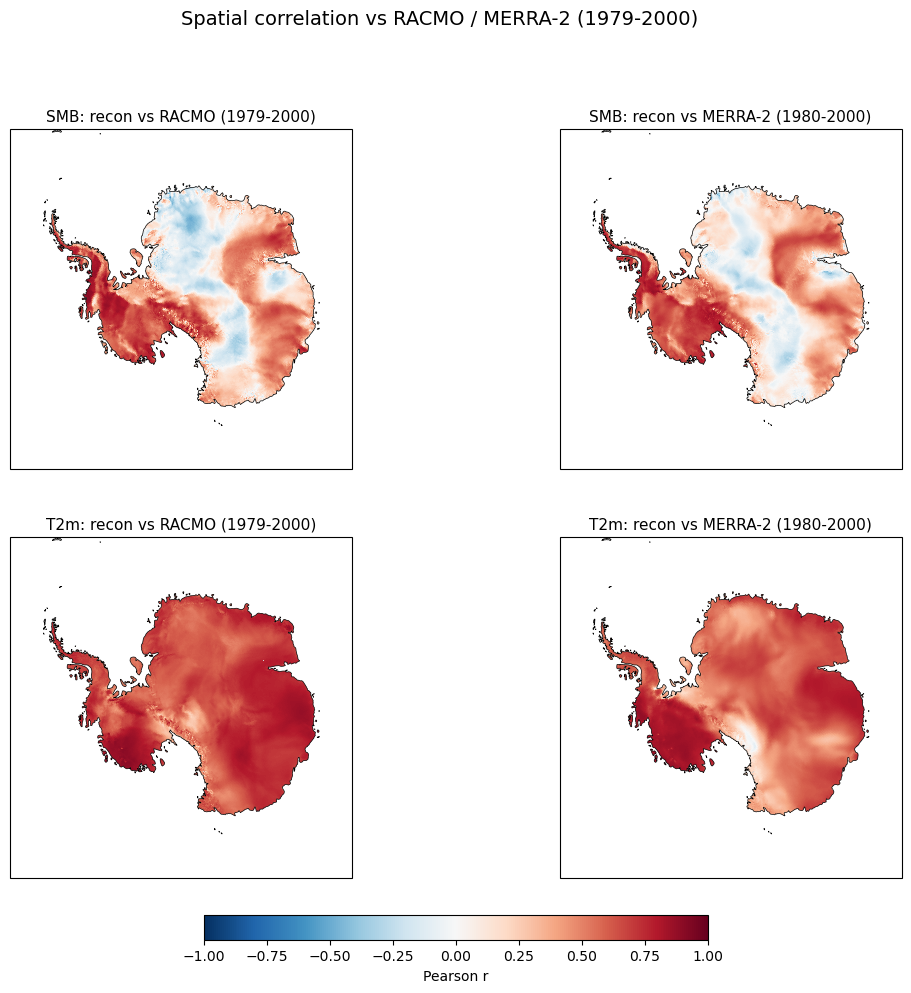

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/2040293288.py:7: RuntimeWarning: Mean of empty slice
  oa = obs - np.nanmean(obs, axis=0); pa = rec - np.nanmean(rec, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/2040293288.py:7: RuntimeWarning: Mean of empty slice
  oa = obs - np.nanmean(obs, axis=0); pa = rec - np.nanmean(rec, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/2040293288.py:7: RuntimeWarning: Mean of empty slice
  oa = obs - np.nanmean(obs, axis=0); pa = rec - np.nanmean(rec, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_96993/2040293288.py:7: RuntimeWarning: Mean of empty slice
  oa = obs - np.nanmean(obs, axis=0); pa = rec - np.nanmean(rec, axis=0)


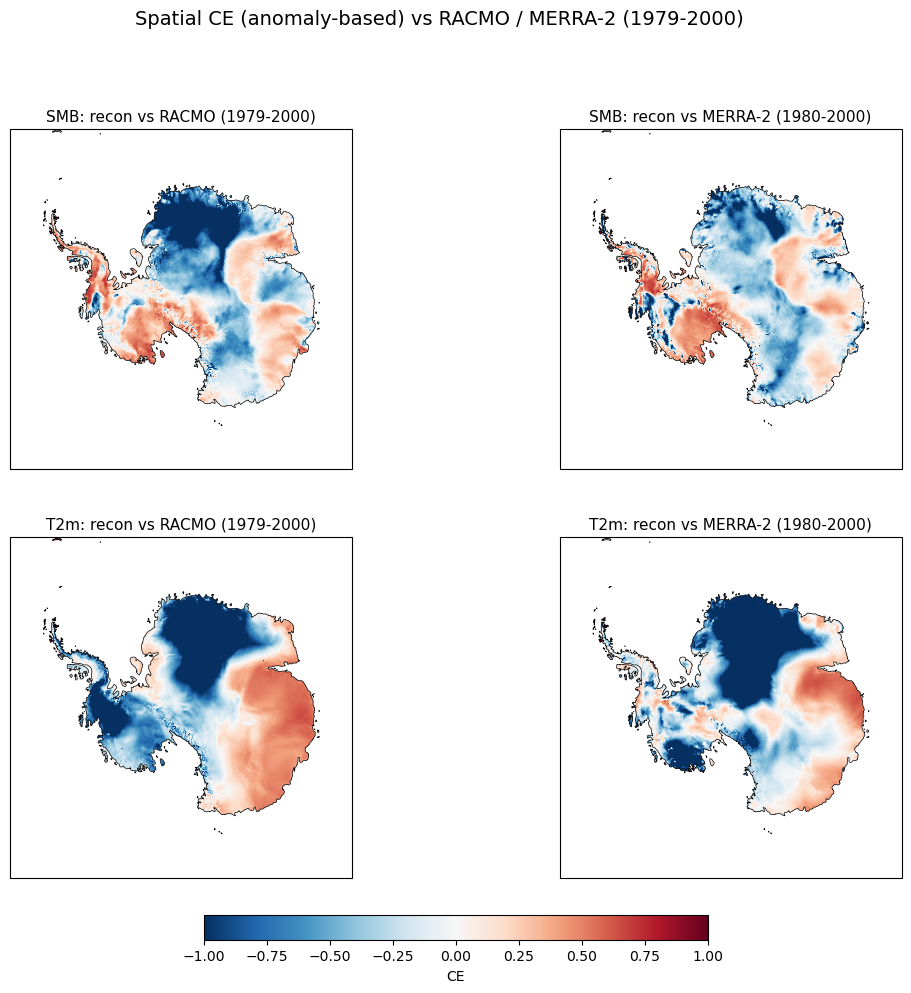

In [30]:
def spatial_corr(rec, obs):
    ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
    num = np.nansum(ra*oa, axis=0); den = np.sqrt(np.nansum(ra**2, axis=0)*np.nansum(oa**2, axis=0))
    with np.errstate(invalid="ignore"):
        return np.where(den > 0, num/den, np.nan)
def spatial_ce(rec, obs):
    oa = obs - np.nanmean(obs, axis=0); pa = rec - np.nanmean(rec, axis=0)
    num = np.nansum((oa-pa)**2, axis=0); den = np.nansum(oa**2, axis=0)
    with np.errstate(invalid="ignore"):
        return np.where(den > 0, 1.0 - num/den, np.nan)
def _align(recon_cube, obs_da, y0=1979, y1=2000):
    yrs = [y for y in range(y0, y1+1) if y in obs_da["year"].values]
    return recon_cube[[y-1801 for y in yrs]], obs_da.sel(year=yrs).values, (yrs[0], yrs[-1])

rows = [("SMB",  racmo_smb_recon,  {"RACMO": smb_ann, "MERRA-2": merra_ann}),
        ("T2m",  racmo_temp_recon, {"RACMO": t2m_ann, "MERRA-2": merra_t2m_ann})]
sources = ["RACMO", "MERRA-2"]
for metric_name, fn, cbar in [("correlation", spatial_corr, "Pearson r"),
                              ("CE (anomaly-based)", spatial_ce, "CE")]:
    fig, axes = plt.subplots(2, 2, figsize=(13, 12), subplot_kw={"projection": ccrs.SouthPolarStereo()})
    im = None
    for i, (var, cube, fields) in enumerate(rows):
        for j, src in enumerate(sources):
            ax = axes[i, j]
            rec, obs, (ya, yb) = _align(cube, fields[src])
            ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
            im = ax.pcolormesh(lon_racmo, lat_racmo, fn(rec, obs), transform=ccrs.PlateCarree(),
                               vmin=-1, vmax=1, cmap="RdBu_r", zorder=1)
            ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
            ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
            ax.set_title(f"{var}: recon vs {src} ({ya}-{yb})", fontsize=11, pad=6)
    cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.04, shrink=0.5); cb.set_label(cbar)
    fig.suptitle(f"Spatial {metric_name} vs RACMO / MERRA-2 (1979-2000)", fontsize=14)
    plt.show()

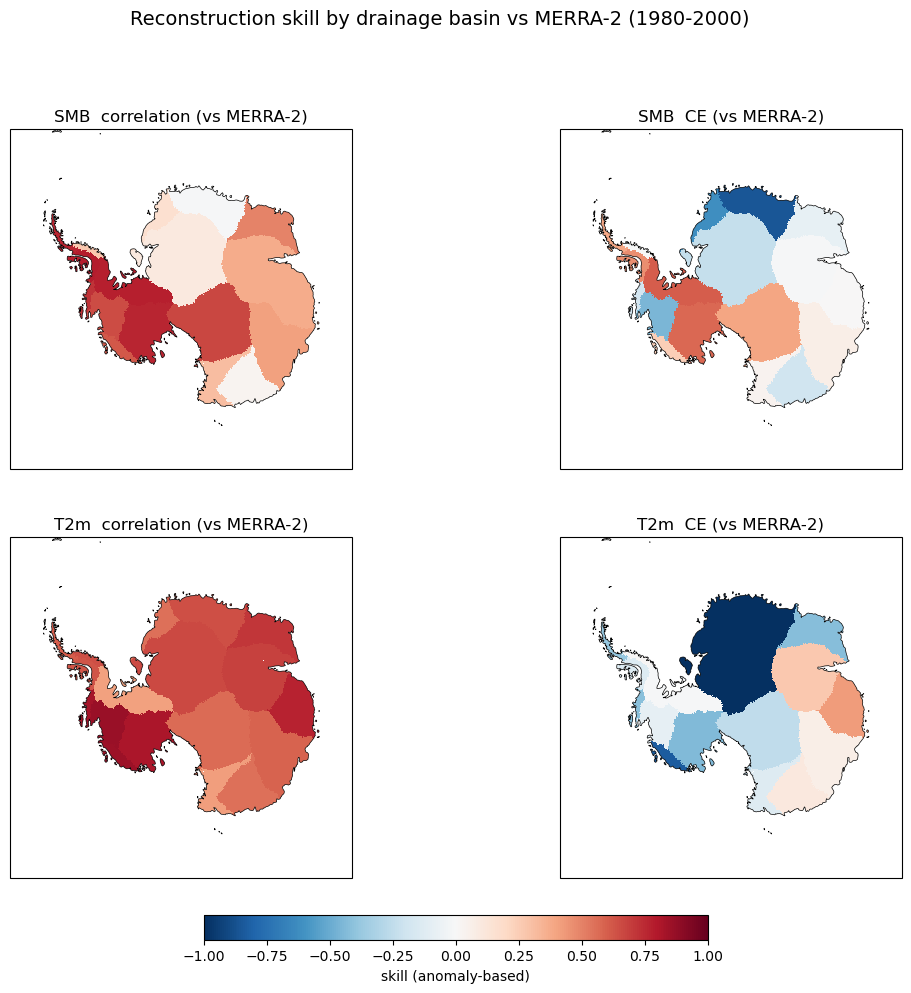

In [39]:
# --- Skill by drainage basin: anomaly correlation & CE, per IMBIE basin, vs MERRA-2 ---
ov = [y for y in range(1980, 2001) if y in merra_years]   # overlap window

def basin_series(field3d, years, bid, kind):
    mk = basin_mask == bid
    if kind == "sum":     # SMB: basin total (Gt/yr)
        return pd.Series([np.nansum(np.where(mk, field3d[t] * cell_area_m2, 0)) / 1e12
                          for t in range(field3d.shape[0])], index=np.asarray(years))
    else:                 # T2m: area-weighted basin mean
        return pd.Series(weighted_avg_series(field3d, mk), index=np.asarray(years))

def basin_skill(recon3d, obs3d, recon_yrs, obs_yrs, kind):
    """Return {basin_id: (r, ce)} on anomalies over the overlap window."""
    out = {}
    for bid in basin_ids_unique:
        rc = basin_series(recon3d, recon_yrs, bid, kind)
        ob = basin_series(obs3d,   obs_yrs,   bid, kind)
        a = rc.reindex(ov).values; b = ob.reindex(ov).values
        v = np.isfinite(a) & np.isfinite(b)
        if v.sum() < 3:
            out[bid] = (np.nan, np.nan); continue
        aa = a[v] - a[v].mean(); bb = b[v] - b[v].mean()
        r  = np.corrcoef(aa, bb)[0, 1]
        ce = 1.0 - np.sum((bb - aa) ** 2) / np.sum(bb ** 2)
        out[bid] = (r, ce)
    return out

def paint(skill_dict, which):     # which: 0=r, 1=ce
    field = np.full(basin_mask.shape, np.nan)
    for bid, vals in skill_dict.items():
        field[basin_mask == bid] = vals[which]
    return field

smb_sk = basin_skill(racmo_smb_recon,  merra_ann.values,     recon_years, merra_years, "sum")
t2m_sk = basin_skill(racmo_temp_recon, merra_t2m_ann.values, recon_years, merra_years, "mean")

panels = [("SMB  correlation", smb_sk, 0), ("SMB  CE", smb_sk, 1),
          ("T2m  correlation", t2m_sk, 0), ("T2m  CE", t2m_sk, 1)]
fig, axes = plt.subplots(2, 2, figsize=(13, 12), subplot_kw={"projection": ccrs.SouthPolarStereo()})
im = None
for ax, (title, sk, which) in zip(axes.ravel(), panels):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint(sk, which), transform=ccrs.PlateCarree(),
                       vmin=-1, vmax=1, cmap="RdBu_r", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(f"{title} (vs MERRA-2)", fontsize=12, pad=6)
cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.04, shrink=0.5)
cb.set_label("skill (anomaly-based)")
fig.suptitle("Reconstruction skill by drainage basin vs MERRA-2 (1980-2000)", fontsize=14)
plt.show()


## 16. Independent validation vs READER station observations

READER Antarctic station annual temperatures (`~/DataFiles/READER/`) compared, in **anomalies**,
to the temperature reconstruction at each station's nearest ANT11 grid cell. Overlap is the
station record up to 2000 (reconstruction end). `*` / bold outline = correlation significant at p<0.05.

     READER station skill vs temperature recon (anomalies)      
(snapped to nearest grounded cell <= 50 km; * = p<0.05; 18/30 sig)
Station               n         r         p        CE
----------------------------------------------------------------
Asuka                 3    0.921      0.255     0.381
Zhongshan            11    0.888*     0.000     0.774
Esperanza            49    0.774*     0.000     0.230
Belgrano_II          19    0.693*     0.001     0.369
Rothera              24    0.670*     0.000     0.440
Casey                41    0.656*     0.000     0.294
O_Higgins            41    0.644*     0.000    -0.449
Halley_5              9    0.609      0.082     0.243
San_Martin           24    0.608*     0.002     0.280
Dumont_Durville      45    0.563*     0.000     0.124
Russkaya              9    0.561      0.116     0.154
Faraday\Vernadsky    54    0.544*     0.000     0.270
Vostok               39    0.536*     0.000    -0.255
Neumayer             19    0.514*     0.024    

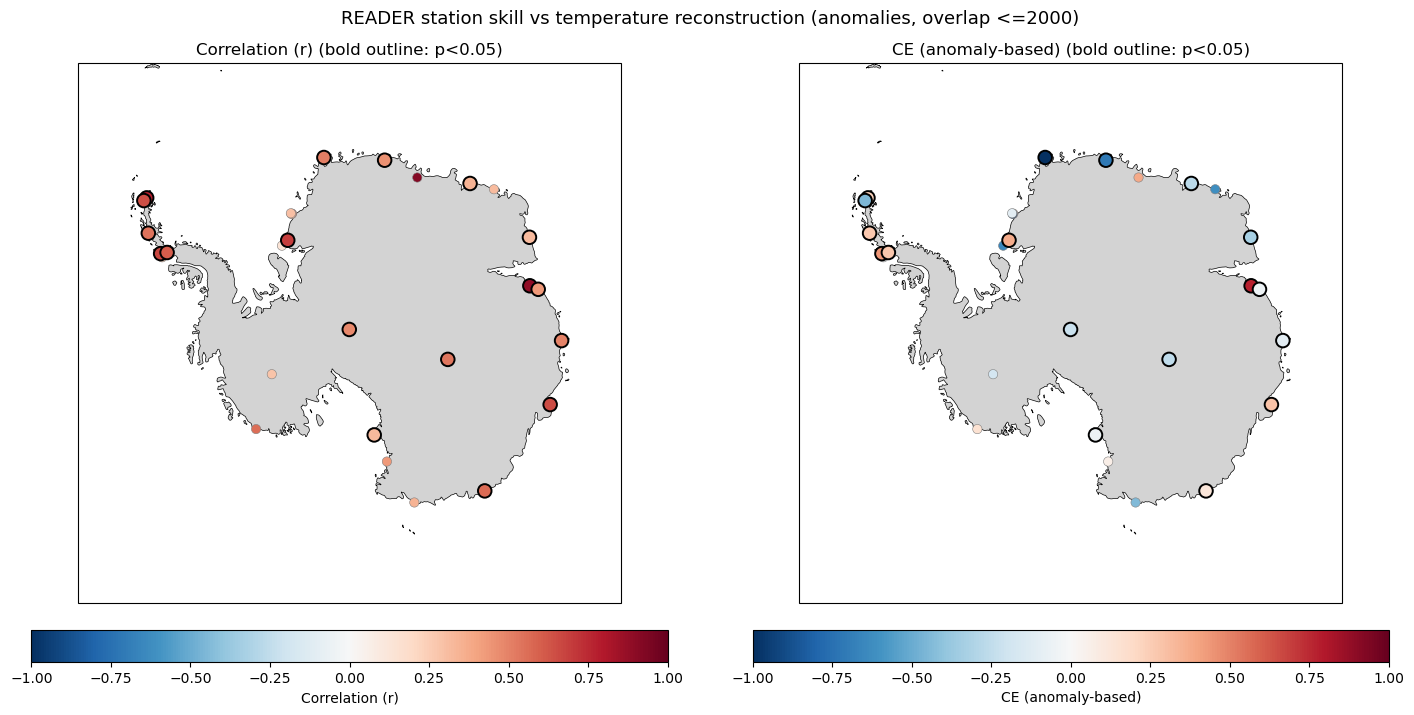

In [34]:
rdir = os.path.expanduser("~/DataFiles/READER")
meta = pd.read_csv(f"{rdir}/reader_station_meta.csv")
wide = pd.read_csv(f"{rdir}/reader_annual_wide.csv", index_col=0)

MIN_STAT = 3; ALPHA_SIG = 0.05
MAX_SNAP_KM = 50.0                       # skip stations farther than this from grounded ice
recon_cube = racmo_temp_recon            # both-proxy temperature reconstruction

# Snap each station to its nearest GROUNDED cell (recon is NaN off the ice sheet)
gidx  = np.argwhere(ice_sheet)                                   # (n_grounded, 2)
gtree = cKDTree(to_xyz(lat_racmo[ice_sheet], lon_racmo[ice_sheet]))

rows = []
for _, m in meta.iterrows():
    st = m.station
    if st not in wide.columns:
        rows.append(dict(station=st, lat=m.lat, lon=m.lon, n=0, r=np.nan, pval=np.nan, ce=np.nan, sig=False)); continue
    d, ii = gtree.query(to_xyz(np.array([m.lat]), np.array([m.lon])))
    if d[0] * 6371.0 > MAX_SNAP_KM:      # too far from grounded ice (e.g. sub-Antarctic island)
        rows.append(dict(station=st, lat=m.lat, lon=m.lon, n=0, r=np.nan, pval=np.nan, ce=np.nan, sig=False)); continue
    j, k = gidx[ii[0]]
    rec = pd.Series(recon_cube[:, j, k], index=recon_years); obs = wide[st]
    common = [y for y in recon_years if y in obs.index and np.isfinite(obs.loc[y]) and np.isfinite(rec.loc[y])]
    n = len(common)
    if n < MIN_STAT:
        rows.append(dict(station=st, lat=m.lat, lon=m.lon, n=n, r=np.nan, pval=np.nan, ce=np.nan, sig=False)); continue
    o = obs.loc[common].values; p = rec.loc[common].values
    oa = o - o.mean(); pa = p - p.mean()
    r, pval = stats.pearsonr(oa, pa)
    ce = 1.0 - np.sum((oa-pa)**2)/np.sum(oa**2)
    rows.append(dict(station=st, lat=m.lat, lon=m.lon, n=n, r=r, pval=pval, ce=ce, sig=pval < ALPHA_SIG))
res = pd.DataFrame(rows).sort_values("r", ascending=False, na_position="last")
scored = res[res.r.notna()]

print("=" * 64)
print("READER station skill vs temperature recon (anomalies)".center(64))
print(f"(snapped to nearest grounded cell <= {MAX_SNAP_KM:.0f} km; * = p<{ALPHA_SIG}; "
      f"{res.sig.sum()}/{len(scored)} sig)".center(64))
print("=" * 64)
print(f"{'Station':<18}{'n':>5}{'r':>10}{'p':>10}{'CE':>10}")
print("-" * 64)
for _, x in res.iterrows():
    if np.isnan(x.r):
        print(f"{x.station:<18}{int(x.n):>5}{'-':>10}{'-':>10}{'-':>10}")
    else:
        print(f"{x.station:<18}{int(x.n):>5}{x.r:>9.3f}{'*' if x.sig else ' '}{x.pval:>10.3f}{x.ce:>10.3f}")
print("-" * 64)
print(f"{'median (scored)':<18}{'':>5}{scored.r.median():>9.3f} {'':>9}{scored.ce.median():>10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
for ax, col, label in [(axes[0], "r", "Correlation (r)"), (axes[1], "ce", "CE (anomaly-based)")]:
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
    ns, sg = scored[~scored.sig], scored[scored.sig]
    ax.scatter(ns.lon, ns.lat, c=ns[col], s=45, cmap="RdBu_r", vmin=-1, vmax=1, zorder=4,
               transform=ccrs.PlateCarree(), edgecolors="gray", linewidths=0.4)
    sc = ax.scatter(sg.lon, sg.lat, c=sg[col], s=95, cmap="RdBu_r", vmin=-1, vmax=1, zorder=5,
                    transform=ccrs.PlateCarree(), edgecolors="black", linewidths=1.4)
    ax.set_title(f"{label} (bold outline: p<{ALPHA_SIG})", fontsize=12)
    fig.colorbar(sc, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85).set_label(label)
fig.suptitle("READER station skill vs temperature reconstruction (anomalies, overlap <=2000)", fontsize=13)
fig.tight_layout(); plt.show()


## 14. Save outputs

In [ ]:
out_dir = os.path.expanduser("~/DataFiles/recon_ANT11")
os.makedirs(out_dir, exist_ok=True)
np.savez_compressed(f"{out_dir}/recon_fields.npz",
                    racmo_smb_recon=racmo_smb_recon, racmo_temp_recon=racmo_temp_recon,
                    lat=lat_racmo, lon=lon_racmo, recon_years=recon_years,
                    basin_mask=basin_mask, cell_area_m2=cell_area_m2)
pd.DataFrame({"year": recon_years, "AIS": ais_rac_recon, "WAIS": wais_rac_recon,
              "EAIS": eais_rac_recon, "AP": ap_rac_recon}).to_csv(f"{out_dir}/smb_basin_recon.csv", index=False)
pd.DataFrame({"year": recon_years, "AIS": ais_temp_recon, "WAIS": wais_temp_recon,
              "EAIS": eais_temp_recon, "AP": ap_temp_recon}).to_csv(f"{out_dir}/temp_basin_recon.csv", index=False)
print("Saved to", out_dir)

Region  SMB base    GRACE      SMB  dynamics  (baseline 1801-1900; trends Gt/yr)
AIS         2361   -114.7    200.1    -314.8
WAIS         839   -158.3     27.3    -185.6
EAIS        1192     68.5    104.1     -35.7
AP           330    -24.8     68.7     -93.5


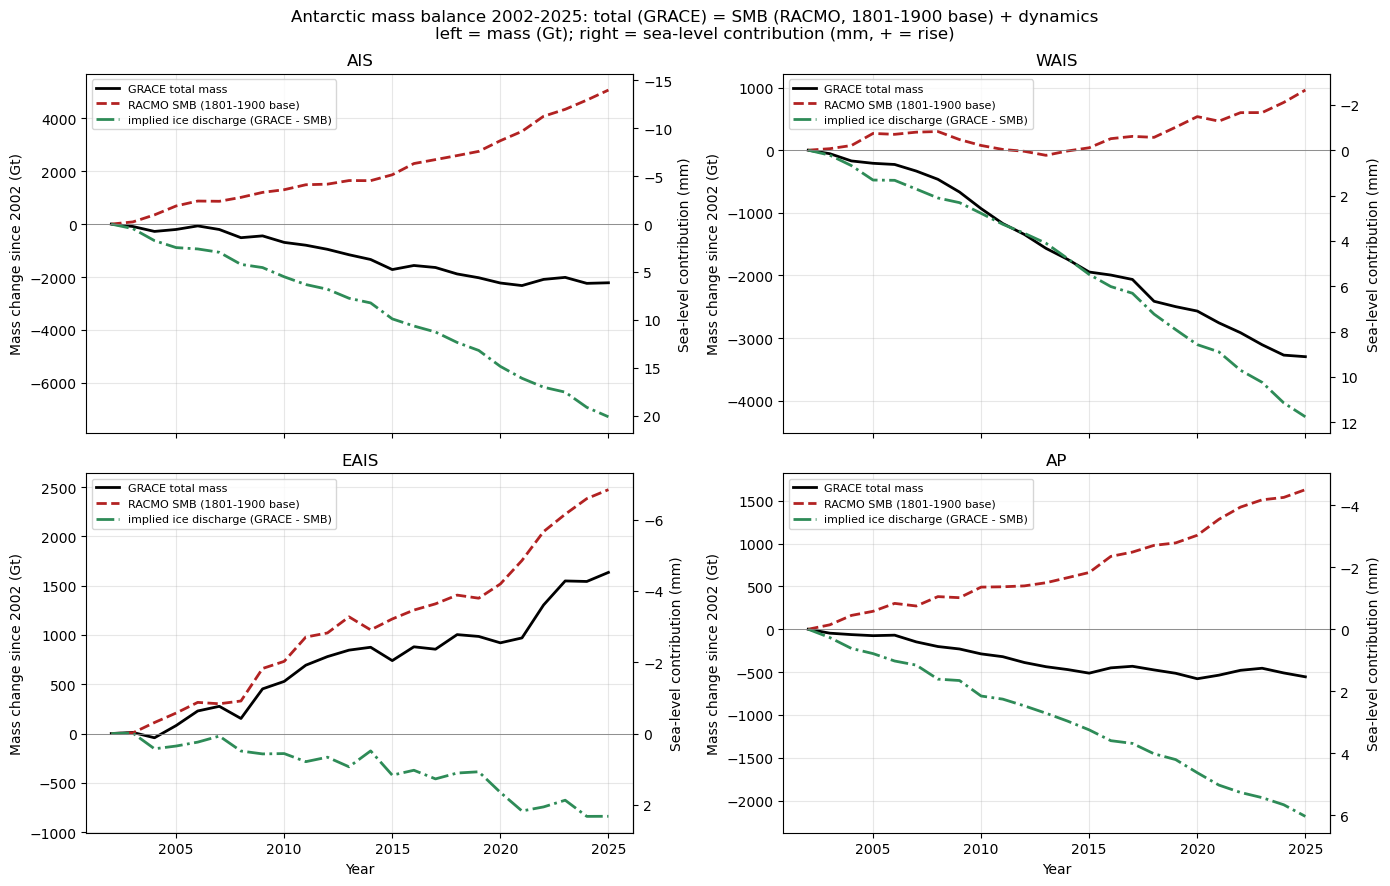

In [101]:
# --- Cumulative mass 2002-2025: GRACE total = RACMO SMB (adjustable baseline) + implied dynamics ---
BASELINE = (1801, 1900)          # <-- change as needed, e.g. (1995, 2010) for a raw-RACMO-only baseline

grace = xr.open_dataset(os.path.expanduser(
    "~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5) *
         (np.sin(np.deg2rad(glat+0.25)) - np.sin(np.deg2rad(glat-0.25))))[:, None] * np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat)
gid = basin_mask[ice_sheet]
d, ii = cKDTree(to_xyz(lat_racmo[ice_sheet], lon_racmo[ice_sheet])).query(
            to_xyz(glat2d.ravel(), glon2d.ravel()))
near = np.where(d * 6371.0 < 150, gid[ii], 0).reshape(glat2d.shape)
grace_masks = {"AIS": near > 0, "WAIS": np.isin(near, [3,7,8,9,10]),
               "EAIS": np.isin(near, [1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(near, [4,5,6])}
gyear = pd.DatetimeIndex(grace["time"].values).year
def grace_annual(mask):
    m = np.array([np.nansum(np.where(mask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
    return pd.Series(m, index=gyear).groupby(level=0).mean()

# Combined SMB series per region: reconstruction 1801-1978, raw RACMO 1979-2025
recon_series = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}
raw_series   = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
def combined_smb(r):
    rec = pd.Series(recon_series[r], index=recon_years)          # 1801-2000
    return pd.concat([rec.loc[:1978], raw_series[r].loc[1979:]]) # 1801-1978 recon + 1979-2025 raw

yrs = np.arange(2002, 2026)
GT_PER_MM = 361.8
def zeroed(s): return s.reindex(yrs) - s.reindex(yrs).loc[2002]
def trend(s):
    y = s.reindex(yrs).values; x = yrs.astype(float); v = np.isfinite(y)
    return np.polyfit(x[v], y[v], 1)[0] if v.sum() > 2 else np.nan

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
print(f"{'Region':<6}{'SMB base':>10}{'GRACE':>9}{'SMB':>9}{'dynamics':>10}  (baseline {BASELINE[0]}-{BASELINE[1]}; trends Gt/yr)")
for ax, r in zip(axes.ravel(), ["AIS", "WAIS", "EAIS", "AP"]):
    comb = combined_smb(r)
    base = comb.loc[BASELINE[0]:BASELINE[1]].mean()             # baseline mean over chosen period
    g   = zeroed(grace_annual(grace_masks[r]))
    c   = zeroed((comb - base).loc[2002:2025].cumsum())         # SMB anomaly cumulative (vs baseline)
    dyn = g - c
    ax.plot(yrs, g.values,   color="black",     lw=2,          label="GRACE total mass")
    ax.plot(yrs, c.values,   color="firebrick", lw=2, ls="--", label=f"RACMO SMB ({BASELINE[0]}-{BASELINE[1]} base)")
    ax.plot(yrs, dyn.values, color="seagreen",  lw=2, ls="-.", label="implied ice discharge (GRACE - SMB)")
    ax.axhline(0, color="gray", lw=0.6)
    ax.set_title(r); ax.set_ylabel("Mass change since 2002 (Gt)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    secax = ax.secondary_yaxis("right", functions=(lambda m: -m / GT_PER_MM, lambda s: -s * GT_PER_MM))
    secax.set_ylabel("Sea-level contribution (mm)")
    print(f"{r:<6}{base:>10.0f}{trend(g):>9.1f}{trend(c):>9.1f}{trend(dyn):>10.1f}")
for ax in axes[-1, :]:
    ax.set_xlabel("Year")
fig.suptitle(f"Antarctic mass balance 2002-2025: total (GRACE) = SMB (RACMO, {BASELINE[0]}-{BASELINE[1]} base) + dynamics\n"
             "left = mass (Gt); right = sea-level contribution (mm, + = rise)", fontsize=12)
fig.tight_layout(); plt.show()


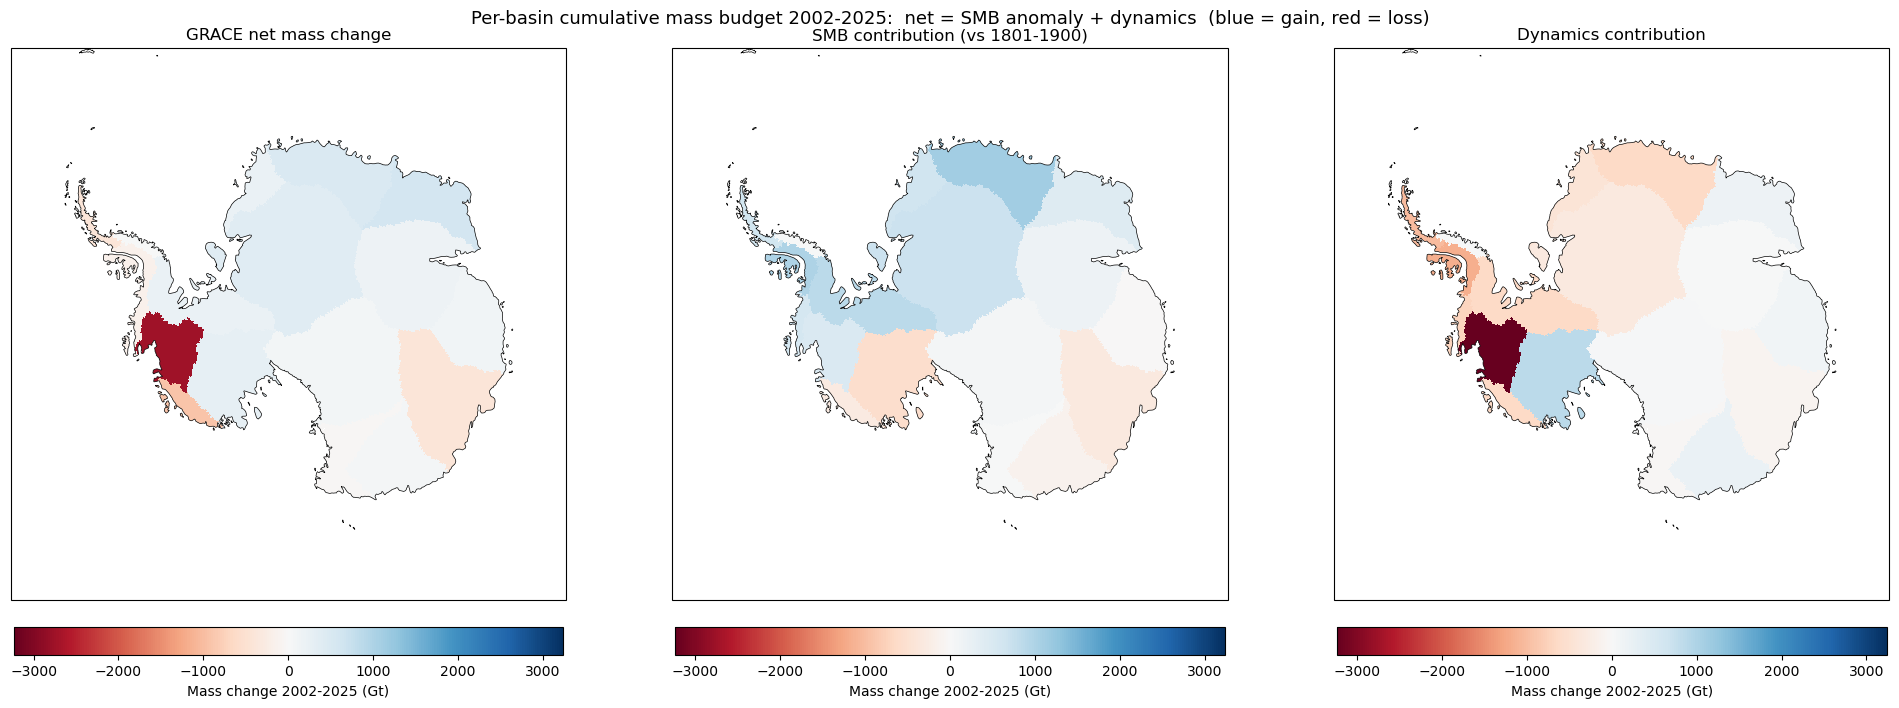

In [102]:
# --- Per-basin cumulative mass change 2002-2025 (Gt): GRACE net = SMB contribution + dynamics ---
BASELINE = (1801, 1900)          # <-- e.g. (1995, 2010) for a raw-RACMO-only baseline
grace = xr.open_dataset(os.path.expanduser(
    "~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5) *
         (np.sin(np.deg2rad(glat+0.25)) - np.sin(np.deg2rad(glat-0.25))))[:, None] * np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat)
gidf = basin_mask[ice_sheet]
d, ii = cKDTree(to_xyz(lat_racmo[ice_sheet], lon_racmo[ice_sheet])).query(
            to_xyz(glat2d.ravel(), glon2d.ravel()))
near_basin = np.where(d * 6371.0 < 150, gidf[ii], 0).reshape(glat2d.shape)
gyear = pd.DatetimeIndex(grace["time"].values).year

y0, y1 = 2002, 2025
dM_grace, dM_smb, dM_dyn = {}, {}, {}
for bid in basin_ids_unique:
    gmask = near_basin == bid
    if gmask.sum() == 0:
        dM_grace[bid] = np.nan
    else:
        m = np.array([np.nansum(np.where(gmask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
        gm = pd.Series(m, index=gyear).groupby(level=0).mean()
        dM_grace[bid] = gm.get(y1, np.nan) - gm.get(y0, np.nan)
    rmask = basin_mask == bid
    smb = pd.Series([np.nansum(np.where(rmask, smb_ann.values[t]*cell_area_m2, 0)) / 1e12
                     for t in range(len(years_obs))], index=years_obs)                  # raw 1979-2025
    comb = pd.concat([smb_basin_recon[bid].loc[:1978], smb.loc[1979:]])                 # recon+raw combined
    base = comb.loc[BASELINE[0]:BASELINE[1]].mean()                                     # baseline over chosen period
    dM_smb[bid] = (smb.loc[y0:y1] - base).sum()
    dM_dyn[bid] = dM_grace[bid] - dM_smb[bid]

def paint(dct):
    f = np.full(basin_mask.shape, np.nan)
    for bid, v in dct.items():
        f[basin_mask == bid] = v
    return f

vmax = np.nanmax(np.abs(list(dM_grace.values()) + list(dM_smb.values()) + list(dM_dyn.values())))
panels = [("GRACE net mass change", dM_grace),
          (f"SMB contribution (vs {BASELINE[0]}-{BASELINE[1]})", dM_smb),
          ("Dynamics contribution", dM_dyn)]
fig, axes = plt.subplots(1, 3, figsize=(20, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
for ax, (title, dct) in zip(axes, panels):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint(dct), transform=ccrs.PlateCarree(),
                       vmin=-vmax, vmax=vmax, cmap="RdBu", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=12, pad=6)
    fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85).set_label("Mass change 2002-2025 (Gt)")
fig.suptitle("Per-basin cumulative mass budget 2002-2025:  net = SMB anomaly + dynamics  (blue = gain, red = loss)",
             fontsize=13)
plt.tight_layout(); plt.show()


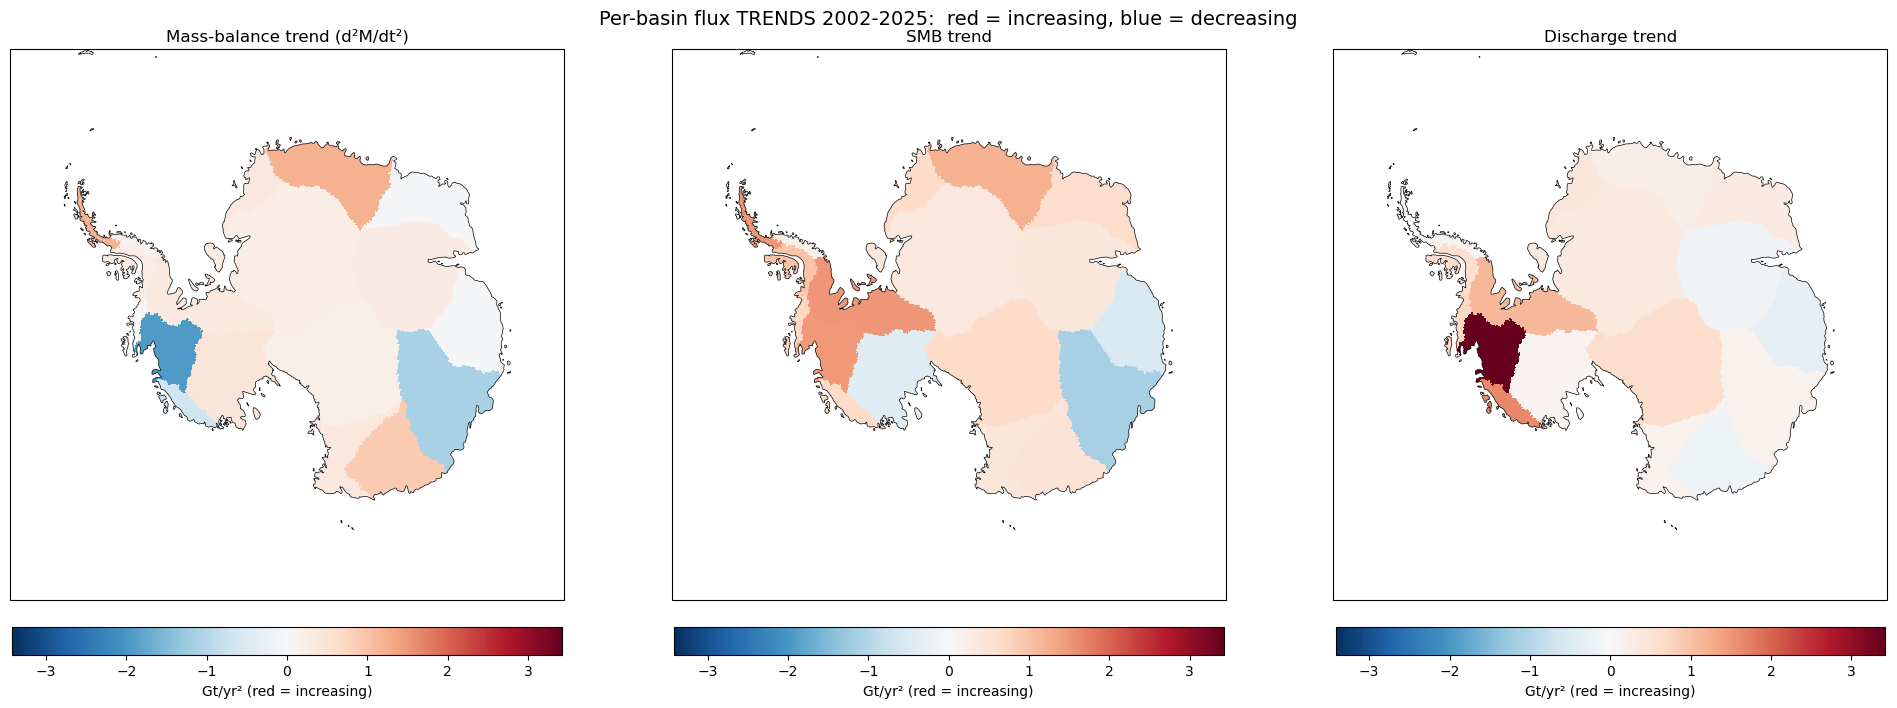

In [91]:
# --- 3-panel per-basin TREND maps: is SMB / discharge / mass balance increasing? (2003-2025) ---
grace = xr.open_dataset(os.path.expanduser(
    "~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5) *
         (np.sin(np.deg2rad(glat+0.25)) - np.sin(np.deg2rad(glat-0.25))))[:, None] * np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat)
gid = basin_mask[ice_sheet]
d, ii = cKDTree(to_xyz(lat_racmo[ice_sheet], lon_racmo[ice_sheet])).query(
            to_xyz(glat2d.ravel(), glon2d.ravel()))
near_basin = np.where(d * 6371.0 < 150, gid[ii], 0).reshape(glat2d.shape)
gyear = pd.DatetimeIndex(grace["time"].values).year
yrs = np.arange(2002, 2026)

def tr(s):
    y = s.reindex(yrs).values; x = yrs.astype(float); v = np.isfinite(y)
    return np.polyfit(x[v], y[v], 1)[0] if v.sum() > 2 else np.nan

mb_acc, smb_tr, d_tr = {}, {}, {}
for bid in basin_ids_unique:
    gmask = near_basin == bid
    rmask = basin_mask == bid
    smb = pd.Series([np.nansum(np.where(rmask, smb_ann.values[t]*cell_area_m2, 0)) / 1e12
                     for t in range(len(years_obs))], index=years_obs)
    if gmask.sum() == 0:
        mb_acc[bid] = smb_tr[bid] = d_tr[bid] = np.nan
        continue
    m = np.array([np.nansum(np.where(gmask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
    gm = pd.Series(m, index=gyear).groupby(level=0).mean()
    dMdt = pd.Series(gm.reindex(yrs).values - gm.reindex(yrs - 1).values, index=yrs)   # mass balance
    D = smb.reindex(yrs) - dMdt                                                          # discharge
    smb_tr[bid] = tr(smb)          # d(SMB)/dt
    mb_acc[bid] = tr(dMdt)         # d(mass balance)/dt  (mass acceleration)
    d_tr[bid]   = tr(D)            # d(discharge)/dt

def paint(dct):
    f = np.full(basin_mask.shape, np.nan)
    for bid, v in dct.items():
        f[basin_mask == bid] = v
    return f

vmax = np.nanmax(np.abs(list(mb_acc.values()) + list(smb_tr.values()) + list(d_tr.values())))
panels = [("Mass-balance trend (d²M/dt²)", mb_acc),
          ("SMB trend",                    smb_tr),
          ("Discharge trend",              d_tr)]

fig, axes = plt.subplots(1, 3, figsize=(20, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
im = None
for ax, (title, dct) in zip(axes, panels):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint(dct), transform=ccrs.PlateCarree(),
                       vmin=-vmax, vmax=vmax, cmap="RdBu_r", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=12, pad=6)
    fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85).set_label("Gt/yr² (red = increasing)")
fig.suptitle("Per-basin flux TRENDS 2002-2025:  red = increasing, blue = decreasing", fontsize=14)
plt.tight_layout(); plt.show()


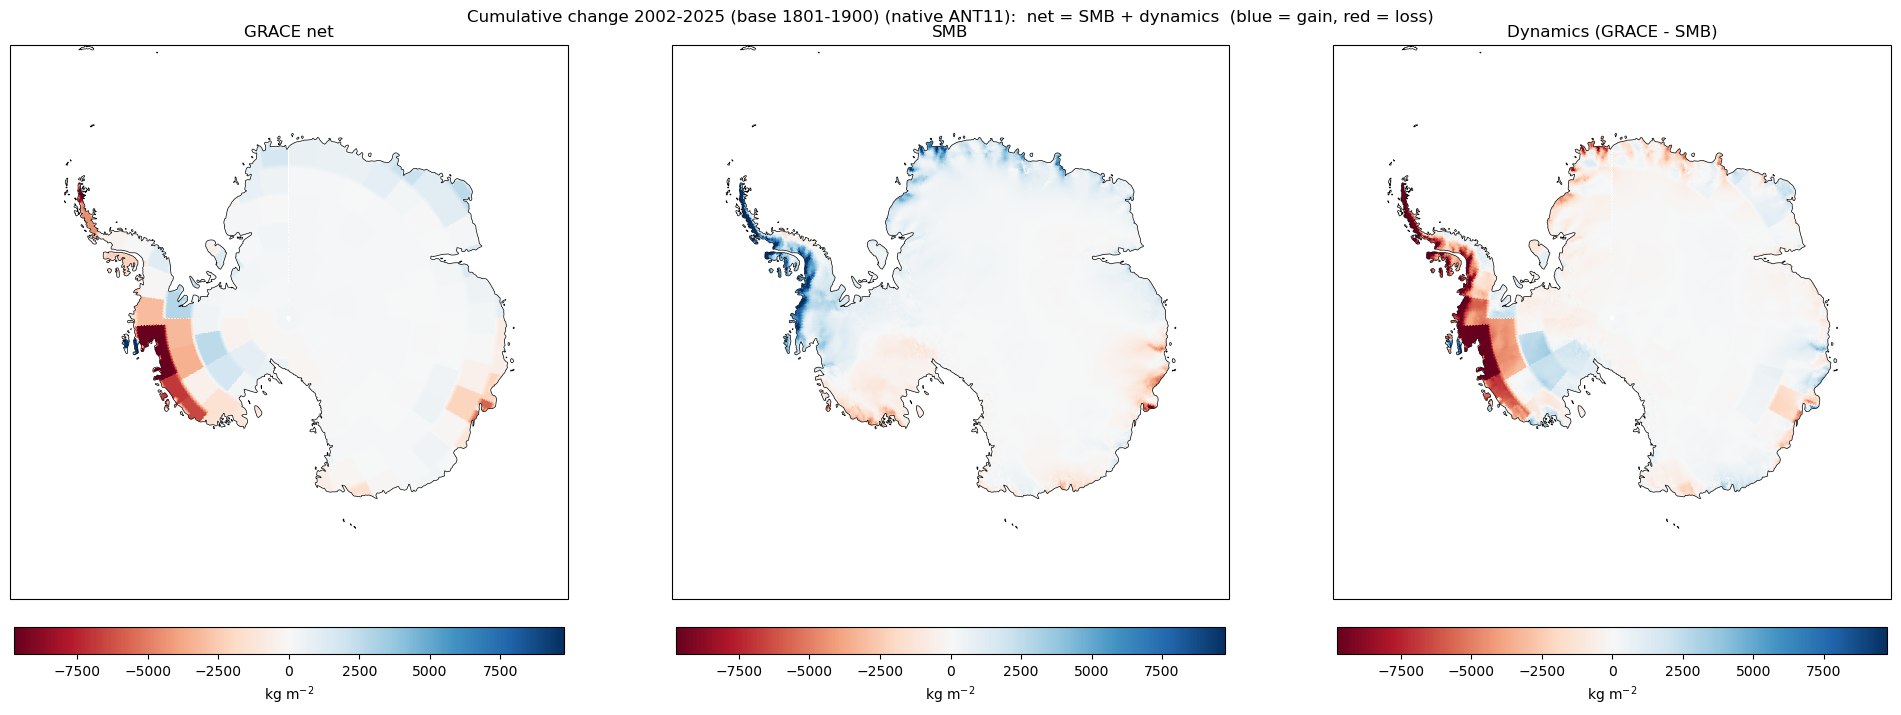

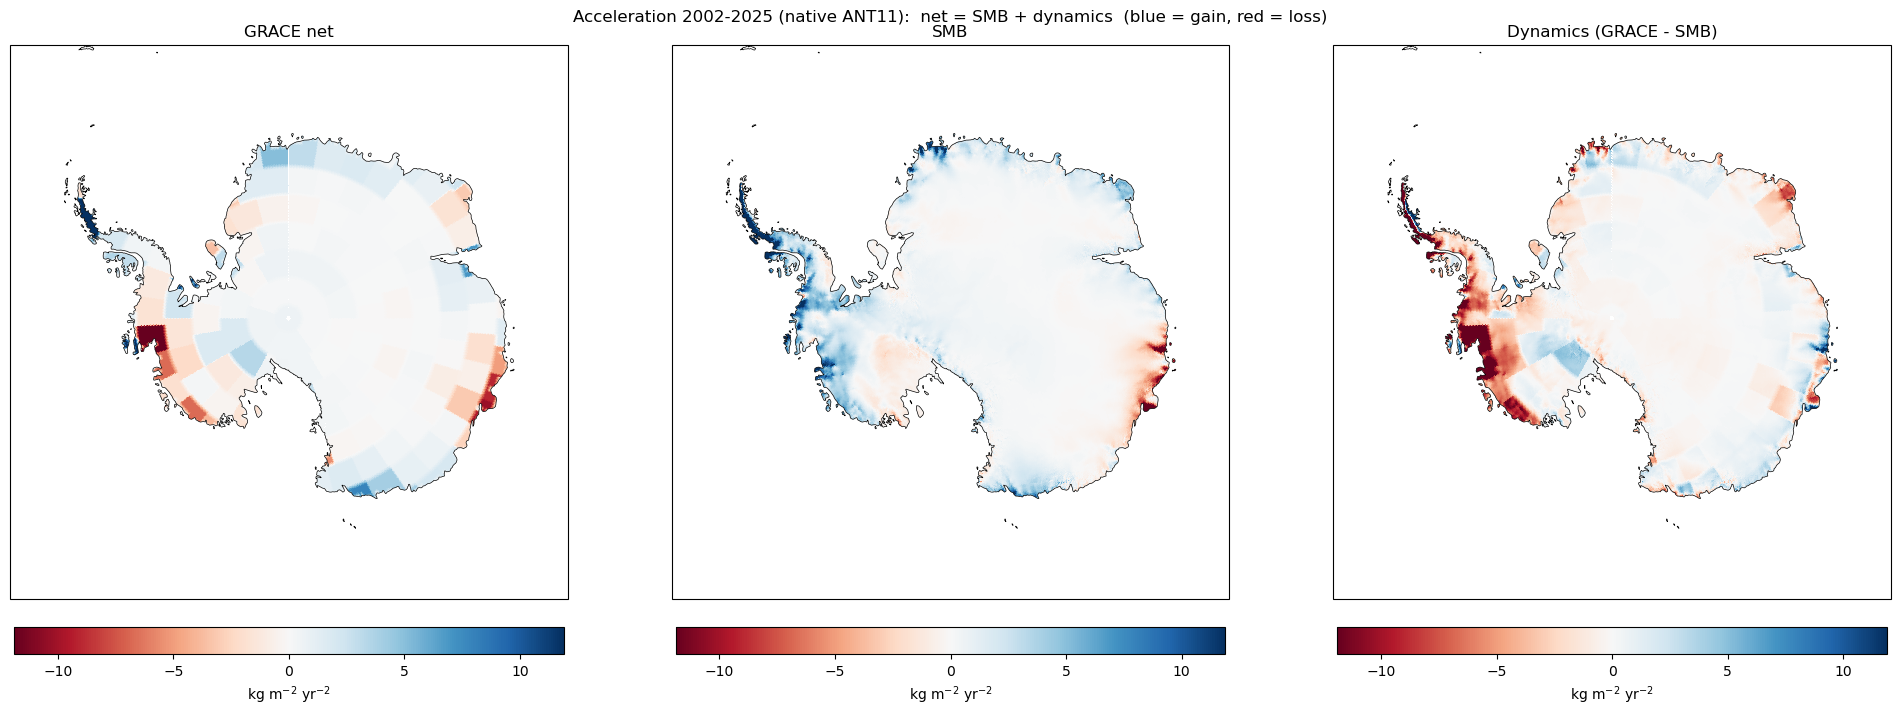

In [103]:
# --- Native-res mass budget 2002-2025: cumulative change (kg/m2) + acceleration (kg/m2/yr2) ---
BASELINE = (1801, 1900)          # <-- adjustable
from scipy.interpolate import RegularGridInterpolator
grace = xr.open_dataset(os.path.expanduser(
    "~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values
gyear = pd.DatetimeIndex(grace["time"].values).year
ann = {int(y): np.nanmean(gsub.values[gyear == y], axis=0) for y in np.unique(gyear)}
def regrid_grace(field2d):
    lon_q = (lon_racmo + 360) % 360
    rgi = RegularGridInterpolator((glat, glon), field2d, bounds_error=False, fill_value=np.nan)
    return rgi(np.stack([lat_racmo.ravel(), lon_q.ravel()], -1)).reshape(NY, NX)
def cell_trend(stack, years):
    A = np.vstack([years.astype(float), np.ones(len(years))]).T
    Y = stack.reshape(len(years), -1); ok = np.isfinite(Y).all(0)
    sl = np.full(Y.shape[1], np.nan); sl[ok] = np.linalg.lstsq(A, Y[:, ok], rcond=None)[0][0]
    return sl.reshape(stack.shape[1:])

# Per-cell baseline over BASELINE, from combined series (recon <=1978, raw >=1979)
def cell_baseline_mean(b0, b1):
    parts, w = [], []
    if b0 <= 1978:
        r1 = min(b1, 1978); parts.append(racmo_smb_recon[b0-1801:r1-1801+1].sum(0)); w.append(r1 - b0 + 1)
    if b1 >= 1979:
        r0 = max(b0, 1979); sel = smb_ann.sel(year=slice(r0, b1)); parts.append(sel.sum("year").values); w.append(sel.sizes["year"])
    return sum(parts) / sum(w)
baseline = cell_baseline_mean(*BASELINE)

grace_net = np.where(ice_sheet, regrid_grace((ann[2025] - ann[2002]) * 10), np.nan)
smb_sel   = smb_ann.sel(year=slice(2002, 2025)); n = smb_sel.sizes["year"]
smb_net   = np.where(ice_sheet, smb_sel.sum("year").values - n * baseline, np.nan)
dyn_net   = grace_net - smb_net

smb_acc = np.where(ice_sheet, cell_trend(smb_ann.sel(year=slice(2002, 2025)).values, np.arange(2002, 2026)), np.nan)
yg = np.arange(2003, 2026)
dmdt = np.array([ann[y] - ann[y - 1] for y in yg]) * 10
mb_acc = np.where(ice_sheet, regrid_grace(cell_trend(dmdt, yg)), np.nan)
dyn_acc = mb_acc - smb_acc

for row_title, g, s, dd, unit in [
        (f"Cumulative change 2002-2025 (base {BASELINE[0]}-{BASELINE[1]})", grace_net, smb_net, dyn_net, "kg m$^{-2}$"),
        ("Acceleration 2002-2025", mb_acc, smb_acc, dyn_acc, "kg m$^{-2}$ yr$^{-2}$")]:
    vmax = np.nanpercentile(np.abs(np.concatenate([g[ice_sheet], s[ice_sheet], dd[ice_sheet]])), 99)
    labs = ["GRACE net", "SMB", "Dynamics (GRACE - SMB)"] if unit.endswith("$^{-2}$") \
           else ["Mass-balance accel.", "SMB accel.", "Dynamics accel."]
    fig, axes = plt.subplots(1, 3, figsize=(20, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
    for ax, title, fld in zip(axes, labs, [g, s, dd]):
        ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
        im = ax.pcolormesh(lon_racmo, lat_racmo, fld, transform=ccrs.PlateCarree(),
                           vmin=-vmax, vmax=vmax, cmap="RdBu", zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        ax.set_title(title, fontsize=12, pad=6)
        fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85).set_label(unit)
    fig.suptitle(f"{row_title} (native ANT11):  net = SMB + dynamics  (blue = gain, red = loss)", fontsize=12)
    plt.tight_layout(); plt.show()


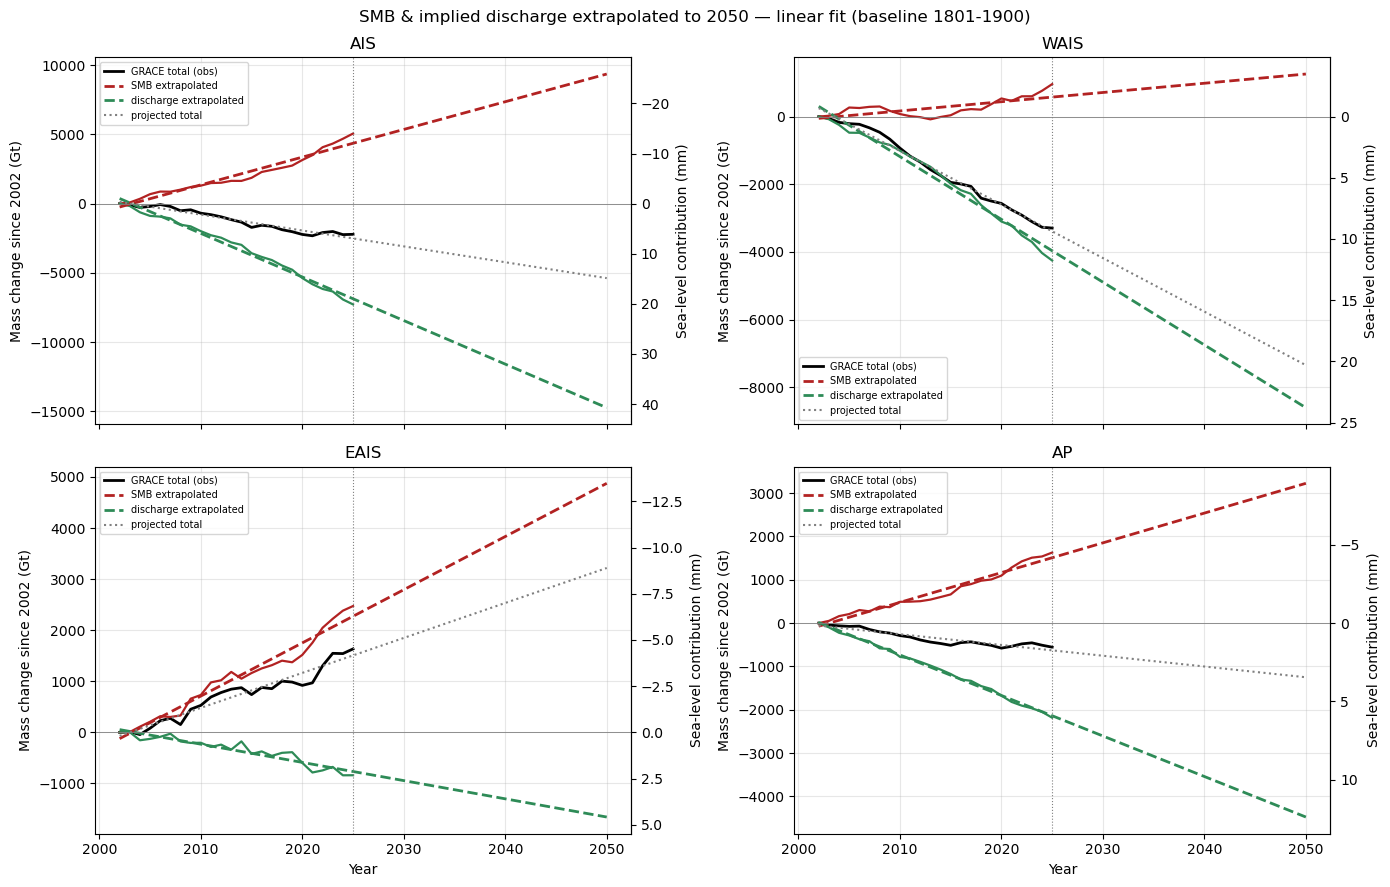

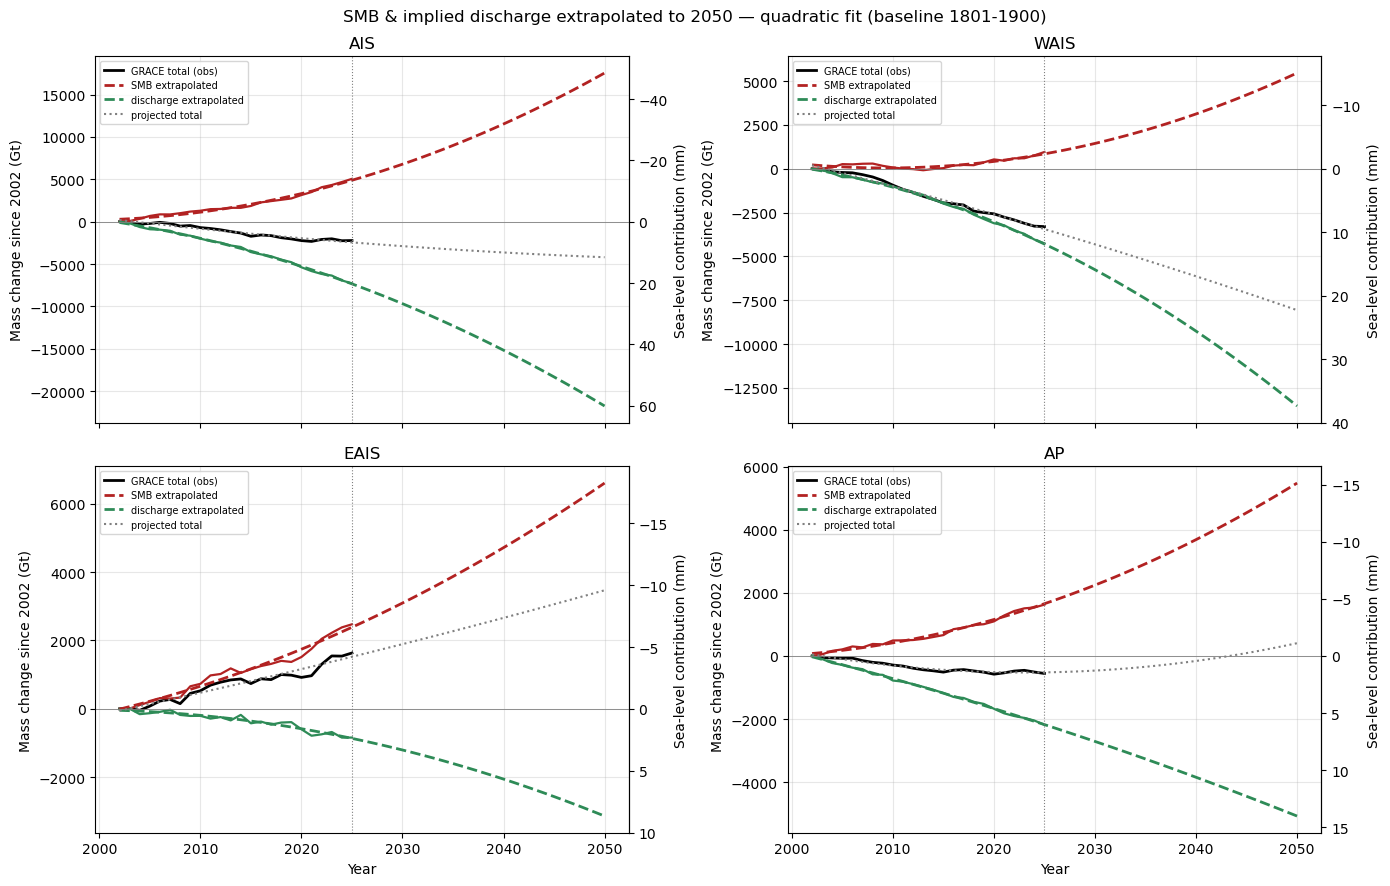

In [104]:
# --- Extrapolate SMB (red) and implied discharge (green): linear and quadratic versions ---
TARGET_YEAR = 2050
BASELINE = (1801, 1900)          # <-- adjustable
grace = xr.open_dataset(os.path.expanduser(
    "~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5) *
         (np.sin(np.deg2rad(glat+0.25)) - np.sin(np.deg2rad(glat-0.25))))[:, None] * np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat)
gidf = basin_mask[ice_sheet]
d, ii = cKDTree(to_xyz(lat_racmo[ice_sheet], lon_racmo[ice_sheet])).query(
            to_xyz(glat2d.ravel(), glon2d.ravel()))
near = np.where(d * 6371.0 < 150, gidf[ii], 0).reshape(glat2d.shape)
grace_masks = {"AIS": near > 0, "WAIS": np.isin(near, [3,7,8,9,10]),
               "EAIS": np.isin(near, [1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(near, [4,5,6])}
gyear = pd.DatetimeIndex(grace["time"].values).year
def grace_annual(mask):
    m = np.array([np.nansum(np.where(mask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
    return pd.Series(m, index=gyear).groupby(level=0).mean()

recon_series = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}
raw_series   = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
def baseline_mean(r):
    comb = pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]])
    return comb.loc[BASELINE[0]:BASELINE[1]].mean()

hist = np.arange(2002, 2026); fut = np.arange(2002, TARGET_YEAR + 1)
GT_PER_MM = 361.8
t = (hist - 2002).astype(float); tf = (fut - 2002).astype(float)
def proj(y, deg):
    v = np.isfinite(y); return np.polyval(np.polyfit(t[v], y[v], deg), tf)

for DEG, name in [(1, "linear"), (2, "quadratic")]:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    for ax, r in zip(axes.ravel(), ["AIS", "WAIS", "EAIS", "AP"]):
        g = grace_annual(grace_masks[r]).reindex(hist)
        black = (g - g.loc[2002]).values
        rc = (raw_series[r] - baseline_mean(r)).loc[2002:2025].cumsum()
        red = (rc - rc.loc[2002]).reindex(hist).values
        green = black - red
        red_ext, green_ext = proj(red, DEG), proj(green, DEG)
        ax.plot(hist, black, "k-", lw=2, label="GRACE total (obs)")
        ax.plot(hist, red,   color="firebrick", lw=1.6)
        ax.plot(hist, green, color="seagreen",  lw=1.6)
        ax.plot(fut, red_ext,   "--", color="firebrick", lw=2, label="SMB extrapolated")
        ax.plot(fut, green_ext, "--", color="seagreen",  lw=2, label="discharge extrapolated")
        ax.plot(fut, red_ext + green_ext, ":", color="gray", lw=1.5, label="projected total")
        ax.axvline(2025, color="gray", lw=0.8, ls=":"); ax.axhline(0, color="gray", lw=0.6)
        ax.set_title(r); ax.set_ylabel("Mass change since 2002 (Gt)")
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
        secax = ax.secondary_yaxis("right", functions=(lambda m: -m / GT_PER_MM, lambda s: -s * GT_PER_MM))
        secax.set_ylabel("Sea-level contribution (mm)")
    for ax in axes[-1, :]:
        ax.set_xlabel("Year")
    fig.suptitle(f"SMB & implied discharge extrapolated to {TARGET_YEAR} \u2014 {name} fit (baseline {BASELINE[0]}-{BASELINE[1]})",
                 fontsize=12)
    fig.tight_layout(); plt.show()
